# Laboratorio 4: Simulación de eventos discretos

**Estudiante:** J. Gregorio Delgado
**Código:** 160005010
**Curso:** Simulación Computacional — Universidad de los Llanos


Contenido:
- **5.1** Sistema de línea de espera con un servidor (G/G/1): escenarios A y B, 10 réplicas.
- **5.2** Red de colas (centro de diagnóstico automotriz): escenarios A y B, 20 réplicas e intervalos de confianza.
- **5.3** Inventario probabilístico.
- **5.4** Simulación de eventos discretos con SimPy: tutoriales y 7 ejemplos oficiales.
- **5.5** AnyLogic (se desarrolla fuera de este notebook).

In [1]:
from pathlib import Path
from collections import deque
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

IMG_DIR = Path('imagenes'); IMG_DIR.mkdir(exist_ok=True)
TAB_DIR = Path('tablas'); TAB_DIR.mkdir(exist_ok=True)
DAT_DIR = Path('datos'); DAT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 10})
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

SEMILLA_BASE = 160005010
INF = math.inf

def normal_truncada(rng, mu, sigma):
    # La guía pide truncar a cero los valores negativos de la normal.
    return max(0.0, rng.normal(mu, sigma))

def resumen(muestras, confianza=0.95):
    # Media muestral, desviación estándar muestral (ddof=1) e IC t-Student.
    x = np.asarray(muestras, dtype=float)
    n = len(x)
    media, s = x.mean(), x.std(ddof=1)
    h = stats.t.ppf((1 + confianza) / 2, n - 1) * s / math.sqrt(n)
    return media, s, media - h, media + h

def num(x, dec=3):
    # Número con coma decimal para LaTeX ({,} evita el espacio extra en modo matemático).
    return f'{x:.{dec}f}'.replace('.', '{,}')

## 5.1. Sistema de línea de espera con un servidor (G/G/1)

Se reescribe el modelo del notebook base (*Sistema de línea de espera con un servidor - G/G/1*, Sec. 5.5.1 de [Rios08]) con el mismo esquema de **programación de sucesos**:

- **Variables de estado:** $t$ (reloj) y $n$ (clientes en el sistema).
- **Lista de sucesos:** $t_{LL}$ (próxima llegada) y $t_S$ (próxima salida); un suceso no programado vale $\infty$.
- **Suceso llegada:** $n\leftarrow n+1$; se genera la próxima llegada solo si ocurre antes de $T$; si el servidor estaba libre ($n=1$) se genera el servicio.
- **Suceso salida:** $n\leftarrow n-1$; si queda alguien en cola se inicia su servicio.
- La simulación termina cuando no hay sucesos pendientes: después de $T$ no entran clientes, pero se atiende a todos los que ya estaban.

**Convención de parámetros.** En el notebook base, `GenerarX()` usa $X=-\ln(1-U)/\lambda$, es decir, $\lambda$ es una **tasa** (media $1/\lambda$).

| Escenario | Tiempo entre llegadas | Tiempo de servicio | Intensidad de tráfico $\rho=\lambda\,E[S]$ |
|---|---|---|---|
| A ($T=40$) | Exp($\lambda=5$), media 0,2 | Exp($\lambda=3$), media 0,333 | $5/3\approx1{,}67$ |
| B ($T=40$) | Exp($\lambda=1$), media 1 | $\max(0,\;N(2,1))$, media $\approx2{,}008$ | $\approx2{,}01$ |

Ambos escenarios tienen $\rho>1$: el servidor no alcanza a atender el flujo de llegadas, así que la cola crece durante $[0,T]$ y se vacía después de $T$.


In [6]:
def simular_gg1(T, gen_llegada, gen_servicio, rng):
    t, n = 0.0, 0
    llegadas, salidas, servicios = [], [], []      # por cliente, en orden FIFO
    traza_t, traza_n = [0.0], [0]

    x = gen_llegada(rng)
    t_ll = x if x < T else INF                      # primera llegada
    t_s = INF

    while t_ll < INF or t_s < INF:
        if t_ll <= t_s:                             # --- suceso: llegada
            t = t_ll
            n += 1
            llegadas.append(t)
            x = gen_llegada(rng)
            t_ll = t + x if t + x < T else INF
            if n == 1:                              # servidor libre: inicia servicio
                y = gen_servicio(rng)
                servicios.append(y)
                t_s = t + y
        else:                                       # --- suceso: salida
            t = t_s
            n -= 1
            salidas.append(t)
            if n > 0:
                y = gen_servicio(rng)
                servicios.append(y)
                t_s = t + y
            else:
                t_s = INF
        traza_t.append(t)
        traza_n.append(n)

    ll, s, sv = np.array(llegadas), np.array(salidas), np.array(servicios)
    NLL = len(ll)
    medidas = {
        't_sistema': (s - ll).mean() if NLL else 0.0,
        't_cola': (s - ll - sv).mean() if NLL else 0.0,
        'Tp': max(0.0, t - T),
        'n_max': max(traza_n),
        'total': NLL,
    }
    traza = dict(t=np.array(traza_t), n=np.array(traza_n), llegadas=ll, salidas=s)
    return medidas, traza

T_GG1 = 40.0
ESC_GG1 = {
    'A': dict(llegada=lambda rng: rng.exponential(1 / 5),
              servicio=lambda rng: rng.exponential(1 / 3)),
    'B': dict(llegada=lambda rng: rng.exponential(1 / 1),
              servicio=lambda rng: normal_truncada(rng, 2.0, 1.0)),
}
NOMBRES_GG1 = {
    't_sistema': 'Tiempo medio de los clientes en el sistema',
    't_cola': 'Tiempo medio de los clientes en la cola',
    'Tp': 'Tiempo transcurrido desde T hasta que el último cliente abandona el sistema',
    'n_max': 'Número máximo de clientes en el sistema',
    'total': 'Total de clientes que pasaron por el sistema',
}

### Una corrida por escenario

Se responde a las cinco preguntas de la guía con una corrida de cada escenario (réplica 0) y se grafican los instantes de llegada y salida y la evolución de $n(t)$.

Escenario A
  Tiempo medio de los clientes en el sistema: 12.4458
  Tiempo medio de los clientes en la cola: 12.1216
  Tiempo transcurrido desde T hasta que el último cliente abandona el sistema: 22.7039
  Número máximo de clientes en el sistema: 70
  Total de clientes que pasaron por el sistema: 192

Escenario B
  Tiempo medio de los clientes en el sistema: 11.0477
  Tiempo medio de los clientes en la cola: 9.2053
  Tiempo transcurrido desde T hasta que el último cliente abandona el sistema: 14.4457
  Número máximo de clientes en el sistema: 10
  Total de clientes que pasaron por el sistema: 28



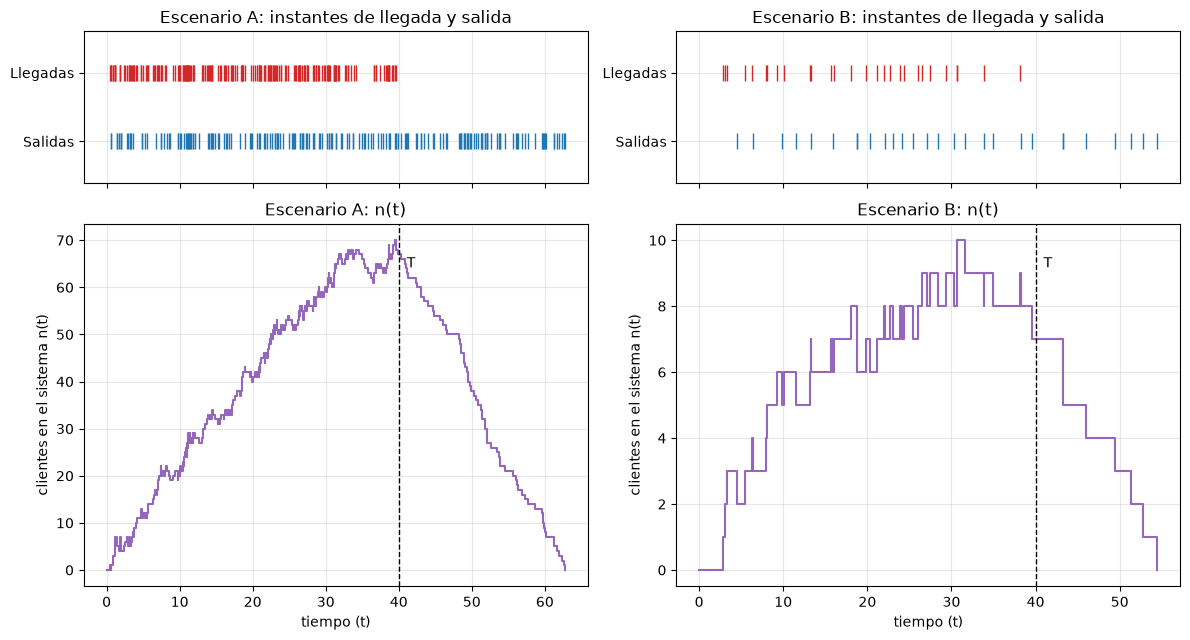

In [7]:
corrida_gg1 = {}
for k, esc in enumerate(ESC_GG1):
    rng = np.random.default_rng(SEMILLA_BASE + 1000 * (k + 1))
    corrida_gg1[esc] = simular_gg1(T_GG1, ESC_GG1[esc]['llegada'], ESC_GG1[esc]['servicio'], rng)

for esc, (m, _) in corrida_gg1.items():
    print(f'Escenario {esc}')
    for clave, nombre in NOMBRES_GG1.items():
        print(f'  {nombre}: {m[clave]:.4f}' if isinstance(m[clave], float) else f'  {nombre}: {m[clave]}')
    print()

fig, ejes = plt.subplots(2, 2, figsize=(12, 6.5), gridspec_kw={'height_ratios': [1, 2.4]}, sharex='col')
for j, (esc, (m, tr)) in enumerate(corrida_gg1.items()):
    ax = ejes[0, j]
    ax.plot(tr['llegadas'], np.full(len(tr['llegadas']), 1.0), '|', color='tab:red', ms=12, label='Llegadas')
    ax.plot(tr['salidas'], np.full(len(tr['salidas']), 0.0), '|', color='tab:blue', ms=12, label='Salidas')
    ax.set_yticks([0, 1], ['Salidas', 'Llegadas']); ax.set_ylim(-0.6, 1.6)
    ax.set_title(f'Escenario {esc}: instantes de llegada y salida')
    ax = ejes[1, j]
    ax.step(tr['t'], tr['n'], where='post', color='tab:purple')
    ax.axvline(T_GG1, color='k', ls='--', lw=1); ax.text(T_GG1, max(tr['n']) * 0.95, '  T', va='top')
    ax.set_xlabel('tiempo (t)'); ax.set_ylabel('clientes en el sistema n(t)')
    ax.set_title(f'Escenario {esc}: n(t)')
fig.tight_layout()
fig.savefig(IMG_DIR / 'gg1_trayectorias.png', bbox_inches='tight')
plt.show()

### 10 réplicas por escenario (Tabla 1)

Cada réplica $i$ del escenario $k$ usa la semilla `SEMILLA_BASE + 1000·k + i`, de modo que las réplicas son independientes y reproducibles.

In [4]:
R_GG1 = 10
replicas_gg1 = {}
for k, esc in enumerate(ESC_GG1):
    filas = []
    for i in range(R_GG1):
        rng = np.random.default_rng(SEMILLA_BASE + 1000 * (k + 1) + i)
        m, _ = simular_gg1(T_GG1, ESC_GG1[esc]['llegada'], ESC_GG1[esc]['servicio'], rng)
        filas.append(m)
    df = pd.DataFrame(filas, index=pd.RangeIndex(1, R_GG1 + 1, name='réplica'))
    replicas_gg1[esc] = df
    df.to_csv(DAT_DIR / f'gg1_replicas_{esc}.csv')
    print(f'Escenario {esc}: datos de las {R_GG1} réplicas')
    display(df)

Escenario A: datos de las 10 réplicas


,t_sistema,t_cola,Tp,n_max,total
réplica,,,,,
1,12.4458,12.1216,22.7039,70,192
2,16.8902,16.5498,35.0396,103,220
3,11.1129,10.8002,20.0690,75,191
4,11.6343,11.3165,23.0374,67,195
5,11.8508,11.5525,21.8274,76,205
6,20.7604,20.4041,37.7956,111,217
7,18.9193,18.5310,33.1207,87,188
8,16.3983,16.0042,41.8772,92,207
9,17.6428,17.3203,30.0494,102,214


Escenario B: datos de las 10 réplicas


,t_sistema,t_cola,Tp,n_max,total
réplica,,,,,
1,11.0477,9.2053,14.4457,10,28
2,26.1647,23.8588,53.0442,23,40
3,22.8474,20.8228,33.7039,20,36
4,28.6152,26.6883,52.0743,27,47
5,19.4868,17.4164,34.9217,17,36
6,26.3170,24.3712,57.5272,28,50
7,29.3884,27.1043,58.3659,27,43
8,20.7026,18.7245,39.6538,21,39
9,13.0389,10.9351,20.9084,12,27


In [5]:
filas = []
for clave, nombre in NOMBRES_GG1.items():
    fila = {'Medida de desempeño': nombre}
    for esc, df in replicas_gg1.items():
        media, s, _, _ = resumen(df[clave])
        fila[f'Escenario {esc}'] = f'{media:.3f} ± {s:.3f}'
    filas.append(fila)
tabla1 = pd.DataFrame(filas).set_index('Medida de desempeño')
display(tabla1)

# Exportación a LaTeX (se incluye en el informe con \input)
lineas = []
for clave, nombre in NOMBRES_GG1.items():
    celdas_tex = []
    for df in replicas_gg1.values():
        media, s, _, _ = resumen(df[clave])
        celdas_tex.append(f'${num(media)} \\pm {num(s)}$')
    lineas.append(f'{nombre} & ' + ' & '.join(celdas_tex) + r' \\')
_ = (TAB_DIR / 'tabla_gg1.tex').write_text('\n'.join(lineas), encoding='utf-8')

,Escenario A,Escenario B
Medida de desempeño,,
Tiempo medio de los clientes en el sistema,14.984 ± 3.525,21.732 ± 6.217
Tiempo medio de los clientes en la cola,14.644 ± 3.505,19.689 ± 6.154
Tiempo transcurrido desde T hasta que el último cliente abandona el sistema,28.732 ± 7.854,40.066 ± 15.127
Número máximo de clientes en el sistema,84.500 ± 16.992,20.400 ± 6.186
Total de clientes que pasaron por el sistema,200.500 ± 14.324,38.500 ± 7.322


### Análisis comparativo (5.1)

**Ambos escenarios son inestables durante $[0,T]$.** Con $\rho>1$ el servidor atiende menos clientes de los que llegan y $n(t)$ crece casi linealmente hasta $T$. Después de $T$ ya no entran clientes y el sistema se vacía a la tasa de servicio. Una aproximación de flujo explica los promedios obtenidos:

| Medida | Aproximación de flujo | A (teórico / simulado) | B (teórico / simulado) |
|---|---|---|---|
| Clientes acumulados en $T$ ≈ $n_{max}$ | $(\lambda-\mu)T$ | $(5-3)\cdot40=80$ / 84,5 | $(1-0{,}5)\cdot40=20$ / 20,4 |
| Tiempo de vaciado $T_p$ | $(\lambda-\mu)T/\mu$ | $80/3\approx26{,}7$ / 28,7 | $20\cdot2=40$ / 40,1 |
| Total de clientes | $\lambda T$ | 200 / 200,5 | 40 / 38,5 |
| Espera media en cola | $\approx(\lambda-\mu)\tfrac{T}{2}\cdot\tfrac1\mu$ | 13,3 / 14,6 | 20 / 19,7 |

(En B, $\mu\approx1/2{,}008$ es la tasa de servicio).

- **Escenario A** tiene muchos más clientes (≈200 frente a ≈39) y una cola máxima cuatro veces mayor (84,5 frente a 20,4). Sin embargo, cada cliente permanece **menos** tiempo (15,0 frente a 21,7), porque su servicio es seis veces más rápido (media 0,33 frente a 2,0).
- **Escenario B** tiene mayor intensidad de tráfico ($\rho\approx2$ frente a 1,67): la cola crece más despacio en número de clientes, pero cada uno espera más, y el vaciado tras $T$ tarda más (40 frente a 29).
- La diferencia entre tiempo en el sistema y en cola es el tiempo medio de servicio: $14{,}98-14{,}64\approx0{,}34\approx1/3$ en A y $21{,}73-19{,}69\approx2{,}04\approx E[\max(0,N(2,1))]=2{,}008$ en B. Esto valida la contabilidad de tiempos.
- La variabilidad relativa es mayor en B (coef. de variación de $T_p$ ≈ 0,38 frente a 0,27): con menos clientes, cada réplica depende más de pocas realizaciones aleatorias.
- Como $\rho>1$, estas medidas **no** describen un estado estacionario (no existe). Dependen de $T$: al duplicar $T$ se duplicarían aproximadamente la cola máxima, $T_p$ y la espera media.

## 5.2. Red de colas

Modelo del centro de diagnóstico automotriz (Sec. 5.5.2 de [Rios08]) con tres nodos de un servidor y disciplina FIFO:

- Los vehículos llegan al **nodo 1** según tiempos entre llegadas exponenciales.
- Al salir del nodo 1 van al **nodo 2** con probabilidad 0,4 y de ahí al nodo 3; con probabilidad 0,6 van directo al **nodo 3**.
- Al salir del nodo 3 abandonan el sistema.
- El servicio en el nodo 3 depende de su congestión: $N(\mu_{31},\sigma_{31})$ si $n_3<5$ y $N(\mu_{32},\sigma_{32})$ si $n_3\ge5$, evaluado al iniciar cada servicio.
- Toda variable normal negativa se trunca a 0.

**Convención de parámetros.** El notebook base genera las llegadas con `np.random.exponential(L)` y el nodo 2 con `np.random.exponential(mu2)`. En NumPy el argumento es la **escala (media)**, así que "$\lambda=2$" se usa como tiempo medio entre llegadas de 2 (unos 150 vehículos en $T=300$, como en la salida del notebook base). Se conserva esa convención.

| Parámetro | Escenario A | Escenario B |
|---|---|---|
| Media entre llegadas | 2 | 3 |
| Nodo 1: $N(\mu_1,\sigma_1)$ | (2,1; 0,5) | (3,0; 1,0) |
| Nodo 2: Exp, media $\mu_2$ | 2,4 | 1,5 |
| Nodo 3 si $n_3<5$ | (4,1; 2,5) | (4,0; 2,0) |
| Nodo 3 si $n_3\ge5$ | (3,0; 2,0) | (2,0; 1,5) |

**Correcciones respecto al notebook base.**
1. Las áreas $\int n_i(t)\,dt$ solo se actualizaban en los sucesos que modificaban el nodo $i$, pero con $(t_{suc}-t)$ medido desde el último suceso *de cualquier nodo*. Por eso se perdía área de los nodos 2 y 3 y $\bar n_2$, $\bar n_3$ quedaban subestimados. Aquí, en cada suceso, se acumula el área de los tres nodos antes de cambiar el estado.
2. El tiempo en el sistema se aproximaba con $\bar W_1 + 0{,}4\,\bar W_2 + \bar W_3$, usando la probabilidad teórica 0,4. Aquí se sigue a cada vehículo por su identificador y se mide exactamente $t_{salida}-t_{llegada}$.
3. Se registra el estado después de **cada** suceso; el bucle original podía procesar varios sucesos en una iteración y guardar solo el último.

In [6]:
def simular_red(T, p, rng, p_nodo2=0.4):
    t = 0.0
    n = [0, 0, 0]                       # clientes en cada nodo
    area = [0.0, 0.0, 0.0]              # integral de n_i(t)
    colas = [deque(), deque(), deque()] # identificadores; el primero está en servicio
    entrada, t_sistema = {}, []
    salidas_nodo = [0, 0, 0]
    prox = {'LL': INF, 'S1': INF, 'S2': INF, 'S3': INF}
    traza = [(0.0, 0, 0, 0)]

    servicio = [
        lambda: normal_truncada(rng, p['mu1'], p['s1']),
        lambda: rng.exponential(p['mu2']),
        lambda: (normal_truncada(rng, p['mu31'], p['s31']) if n[2] < 5
                 else normal_truncada(rng, p['mu32'], p['s32'])),
    ]

    def entrar(i, cid):
        colas[i].append(cid)
        n[i] += 1
        if n[i] == 1:                              # nodo libre: inicia servicio
            prox[f'S{i+1}'] = t + servicio[i]()

    def salir(i):
        cid = colas[i].popleft()
        n[i] -= 1
        salidas_nodo[i] += 1
        if n[i] > 0:                               # atiende al siguiente de la cola
            prox[f'S{i+1}'] = t + servicio[i]()
        return cid

    x = rng.exponential(p['L'])
    prox['LL'] = x if x < T else INF
    siguiente_id = 0

    while True:
        suceso = min(prox, key=prox.get)
        t_suc = prox[suceso]
        if t_suc == INF:
            break
        for i in range(3):
            area[i] += n[i] * (t_suc - t)
        t = t_suc
        prox[suceso] = INF

        if suceso == 'LL':
            entrada[siguiente_id] = t
            entrar(0, siguiente_id)
            siguiente_id += 1
            x = rng.exponential(p['L'])
            prox['LL'] = t + x if t + x < T else INF
        elif suceso == 'S1':
            cid = salir(0)
            entrar(1 if rng.uniform() <= p_nodo2 else 2, cid)
        elif suceso == 'S2':
            entrar(2, salir(1))
        else:
            cid = salir(2)
            t_sistema.append(t - entrada.pop(cid))
        traza.append((t, *n))

    traza = np.array(traza)
    medidas = {
        't_med_sistema': np.mean(t_sistema) if t_sistema else 0.0,
        'n_med_n1': area[0] / t if t > 0 else 0.0,
        'n_med_n2': area[1] / t if t > 0 else 0.0,
        'n_med_n3': area[2] / t if t > 0 else 0.0,
        'Tp': max(0.0, t - T),
        'n_max': int(traza[:, 1:].sum(axis=1).max()),
        'n1': salidas_nodo[0],
        'n2': salidas_nodo[1],
        'n3': salidas_nodo[2],
        'total': salidas_nodo[2],
    }
    return medidas, traza

T_RED = 300.0
ESC_RED = {
    'A': dict(L=2.0, mu1=2.1, s1=0.5, mu2=2.4, mu31=4.1, s31=2.5, mu32=3.0, s32=2.0),
    'B': dict(L=3.0, mu1=3.0, s1=1.0, mu2=1.5, mu31=4.0, s31=2.0, mu32=2.0, s32=1.5),
}
NOMBRES_RED = {
    't_med_sistema': 'Tiempo medio de los clientes en el sistema',
    'n_med_n1': 'Número promedio de clientes en el nodo 1',
    'n_med_n2': 'Número promedio de clientes en el nodo 2',
    'n_med_n3': 'Número promedio de clientes en el nodo 3',
    'Tp': 'Tiempo desde T hasta que el último cliente abandona el sistema',
    'n_max': 'Número máximo de clientes en el sistema',
    'n1': 'Total de clientes que pasaron por el nodo 1',
    'n2': 'Total de clientes que pasaron por el nodo 2',
    'n3': 'Total de clientes que pasaron por el nodo 3',
    'total': 'Total de clientes que pasaron por el sistema',
}

### Una corrida por escenario

Escenario A
  Tiempo medio de los clientes en el sistema (t_med_sistema): 158.3227
  Número promedio de clientes en el nodo 1 (n_med_n1): 13.2466
  Número promedio de clientes en el nodo 2 (n_med_n2): 0.3838
  Número promedio de clientes en el nodo 3 (n_med_n3): 32.5115
  Tiempo desde T hasta que el último cliente abandona el sistema (Tp): 303.8924
  Número máximo de clientes en el sistema (n_max): 95
  Total de clientes que pasaron por el nodo 1 (n1): 176
  Total de clientes que pasaron por el nodo 2 (n2): 69
  Total de clientes que pasaron por el nodo 3 (n3): 176
  Total de clientes que pasaron por el sistema (total): 176

Escenario B
  Tiempo medio de los clientes en el sistema (t_med_sistema): 28.7842
  Número promedio de clientes en el nodo 1 (n_med_n1): 3.3659
  Número promedio de clientes en el nodo 2 (n_med_n2): 0.1994
  Número promedio de clientes en el nodo 3 (n_med_n3): 4.9496
  Tiempo desde T hasta que el último cliente abandona el sistema (Tp): 21.1444
  Número máximo de c

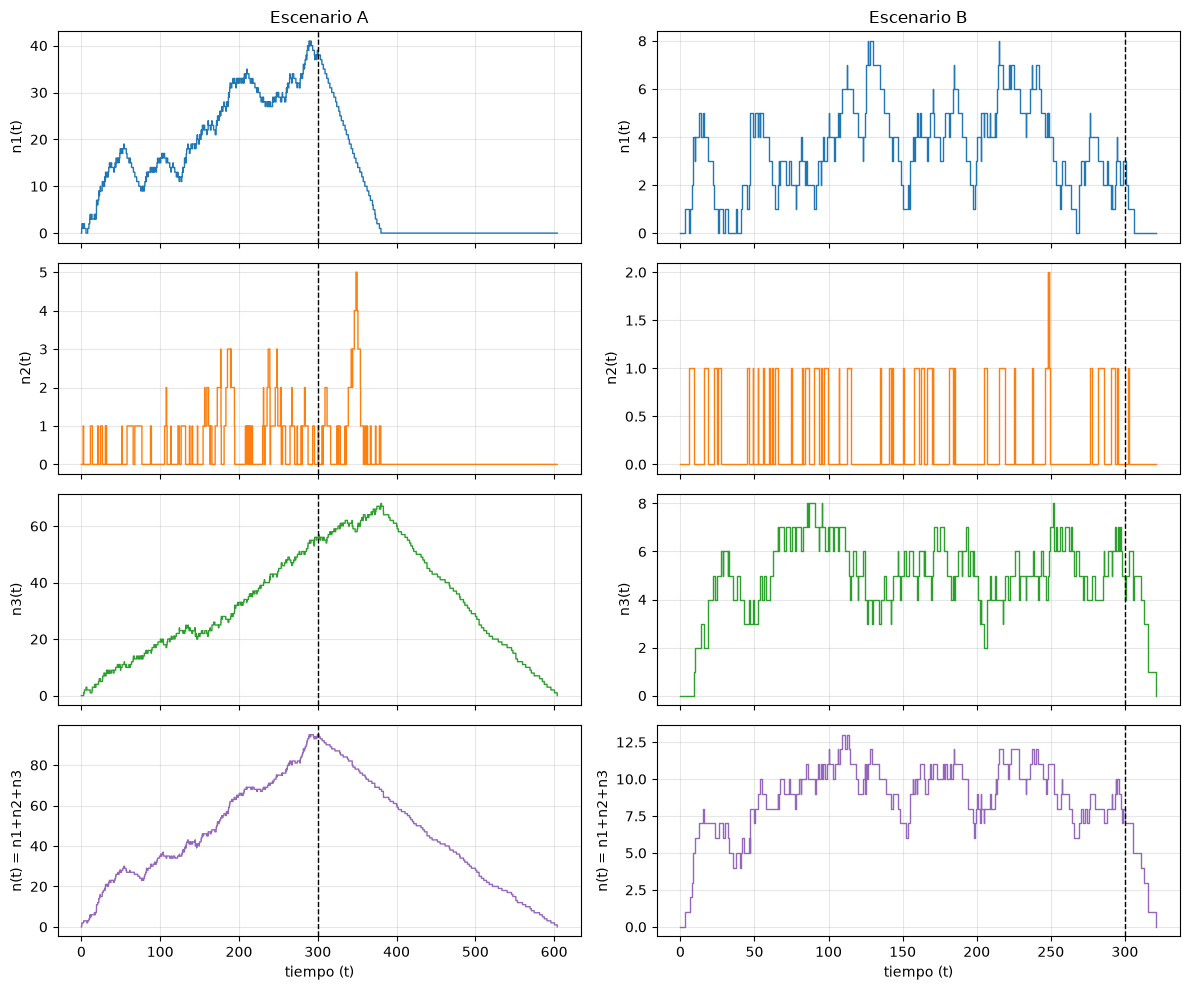

In [7]:
corrida_red = {}
for k, esc in enumerate(ESC_RED):
    rng = np.random.default_rng(SEMILLA_BASE + 5000 + 1000 * (k + 1))
    corrida_red[esc] = simular_red(T_RED, ESC_RED[esc], rng)

for esc, (m, _) in corrida_red.items():
    print(f'Escenario {esc}')
    for clave, nombre in NOMBRES_RED.items():
        v = m[clave]
        print(f'  {nombre} ({clave}): {v:.4f}' if isinstance(v, float) else f'  {nombre} ({clave}): {v}')
    print()

fig, ejes = plt.subplots(4, 2, figsize=(12, 10), sharex='col')
etiquetas = ['n1(t)', 'n2(t)', 'n3(t)', 'n(t) = n1+n2+n3']
colores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
for j, (esc, (m, tr)) in enumerate(corrida_red.items()):
    series = [tr[:, 1], tr[:, 2], tr[:, 3], tr[:, 1:].sum(axis=1)]
    for i in range(4):
        ax = ejes[i, j]
        ax.step(tr[:, 0], series[i], where='post', color=colores[i], lw=1)
        ax.axvline(T_RED, color='k', ls='--', lw=1)
        ax.set_ylabel(etiquetas[i])
    ejes[0, j].set_title(f'Escenario {esc}')
    ejes[3, j].set_xlabel('tiempo (t)')
fig.tight_layout()
fig.savefig(IMG_DIR / 'red_trayectorias.png', bbox_inches='tight')
plt.show()

### 20 réplicas por escenario: media, desviación estándar e IC al 95 %

Para cada medida $X$ con $R=20$ réplicas independientes:

$$\bar X=\frac1R\sum_{r=1}^R X_r,\qquad S=\sqrt{\frac{1}{R-1}\sum_{r=1}^R (X_r-\bar X)^2},\qquad \bar X \pm t_{0{,}975,\,R-1}\,\frac{S}{\sqrt R},$$

con $t_{0{,}975,19}\approx 2{,}093$.

In [8]:
R_RED = 20
replicas_red = {}
for k, esc in enumerate(ESC_RED):
    filas = []
    for i in range(R_RED):
        rng = np.random.default_rng(SEMILLA_BASE + 5000 + 1000 * (k + 1) + i)
        m, _ = simular_red(T_RED, ESC_RED[esc], rng)
        filas.append(m)
    df = pd.DataFrame(filas, index=pd.RangeIndex(1, R_RED + 1, name='réplica'))
    replicas_red[esc] = df
    df.to_csv(DAT_DIR / f'red_replicas_{esc}.csv')
    print(f'Escenario {esc}: datos de las {R_RED} réplicas')
    display(df)

Escenario A: datos de las 20 réplicas


,t_med_sistema,n_med_n1,n_med_n2,n_med_n3,Tp,n_max,n1,n2,n3,total
réplica,,,,,,,,,,
1,158.3227,13.2466,0.3838,32.5115,303.8924,95,176,69,176,176
2,101.9860,3.5646,0.2903,27.3804,189.7648,65,150,48,150,150
3,66.8038,2.4296,0.3507,18.1735,146.3429,46,140,58,140,140
4,78.8670,2.2262,0.4786,21.5461,139.0382,48,135,61,135,135
5,96.8283,6.2222,0.2464,24.4677,182.0089,61,154,58,154,154
6,105.8745,4.2592,0.3448,24.9550,194.2892,57,138,44,138,138
7,51.9541,1.8164,0.4981,14.4369,93.8890,28,127,48,127,127
8,84.8200,4.4224,0.3859,20.5569,168.1541,53,140,59,140,140
9,107.4853,4.5619,0.3494,27.7792,226.0753,72,160,69,160,160


Escenario B: datos de las 20 réplicas


,t_med_sistema,n_med_n1,n_med_n2,n_med_n3,Tp,n_max,n1,n2,n3,total
réplica,,,,,,,,,,
1,28.7842,3.3659,0.1994,4.9496,21.1444,13,95,41,95,95
2,34.1883,6.4514,0.1948,3.5037,40.2020,18,101,34,101,101
3,56.0179,11.7095,0.1711,4.4696,49.4635,29,102,41,102,102
4,27.9414,4.5069,0.1914,3.7376,37.8475,17,102,40,102,102
5,21.7509,2.2161,0.1618,3.4976,29.4734,13,89,35,89,89
6,34.2718,5.1420,0.2774,3.6882,61.2457,20,96,40,96,96
7,26.9279,3.4300,0.1416,4.3705,25.4927,14,96,38,96,96
8,27.2230,3.6250,0.2296,4.2765,31.4520,16,99,38,99,99
9,54.1490,11.5791,0.2730,4.2511,59.8012,27,107,48,107,107


In [9]:
print(f't(0.975, {R_RED-1}) = {stats.t.ppf(0.975, R_RED-1):.4f}')
resumen_red = {}
for esc, df in replicas_red.items():
    filas = []
    for clave, nombre in NOMBRES_RED.items():
        media, s, li, ls = resumen(df[clave])
        filas.append({'Medida': nombre, 'Media': media, 'Desv. estándar': s,
                      'IC95 inf': li, 'IC95 sup': ls, 'Semiancho': (ls - li) / 2,
                      'Semiancho relativo %': 100 * (ls - li) / 2 / media if media else np.nan})
    resumen_red[esc] = pd.DataFrame(filas).set_index('Medida')
    print(f'\nEscenario {esc}')
    display(resumen_red[esc])

# Exportación a LaTeX: una tabla por escenario
for esc, res in resumen_red.items():
    lineas = []
    for nombre, f in res.iterrows():
        lineas.append(f"{nombre} & {num(f['Media'])} & {num(f['Desv. estándar'])} & "
                      f"[{num(f['IC95 inf'])};\\ {num(f['IC95 sup'])}] \\\\")
    _ = (TAB_DIR / f'tabla_red_{esc}.tex').write_text('\n'.join(lineas), encoding='utf-8')

t(0.975, 19) = 2.0930

Escenario A


,Media,Desv. estándar,IC95 inf,IC95 sup,Semiancho,Semiancho relativo %
Medida,,,,,,
Tiempo medio de los clientes en el sistema,94.5944,25.1187,82.8385,106.3504,11.7559,12.4277
Número promedio de clientes en el nodo 1,5.1318,2.9568,3.7479,6.5156,1.3838,26.9658
Número promedio de clientes en el nodo 2,0.3970,0.0963,0.3519,0.4420,0.0451,11.3541
Número promedio de clientes en el nodo 3,23.4401,5.0361,21.0831,25.7971,2.3570,10.0554
Tiempo desde T hasta que el último cliente abandona el sistema,176.6195,46.6797,154.7727,198.4662,21.8468,12.3694
Número máximo de clientes en el sistema,57.2500,14.6786,50.3802,64.1198,6.8698,11.9996
Total de clientes que pasaron por el nodo 1,146.3000,12.9700,140.2299,152.3701,6.0701,4.1491
Total de clientes que pasaron por el nodo 2,57.6000,7.3442,54.1628,61.0372,3.4372,5.9673
Total de clientes que pasaron por el nodo 3,146.3000,12.9700,140.2299,152.3701,6.0701,4.1491



Escenario B


,Media,Desv. estándar,IC95 inf,IC95 sup,Semiancho,Semiancho relativo %
Medida,,,,,,
Tiempo medio de los clientes en el sistema,33.1540,11.2739,27.8777,38.4304,5.2763,15.9146
Número promedio de clientes en el nodo 1,5.4327,3.3465,3.8665,6.9990,1.5662,28.8294
Número promedio de clientes en el nodo 2,0.1967,0.0426,0.1768,0.2167,0.0199,10.1332
Número promedio de clientes en el nodo 3,4.0343,0.4383,3.8292,4.2394,0.2051,5.0843
Tiempo desde T hasta que el último cliente abandona el sistema,38.2577,19.1880,29.2774,47.2379,8.9803,23.4731
Número máximo de clientes en el sistema,18.3000,6.0880,15.4508,21.1492,2.8492,15.5697
Total de clientes que pasaron por el nodo 1,97.7500,8.8131,93.6253,101.8747,4.1247,4.2196
Total de clientes que pasaron por el nodo 2,38.4000,4.9460,36.0852,40.7148,2.3148,6.0282
Total de clientes que pasaron por el nodo 3,97.7500,8.8131,93.6253,101.8747,4.1247,4.2196


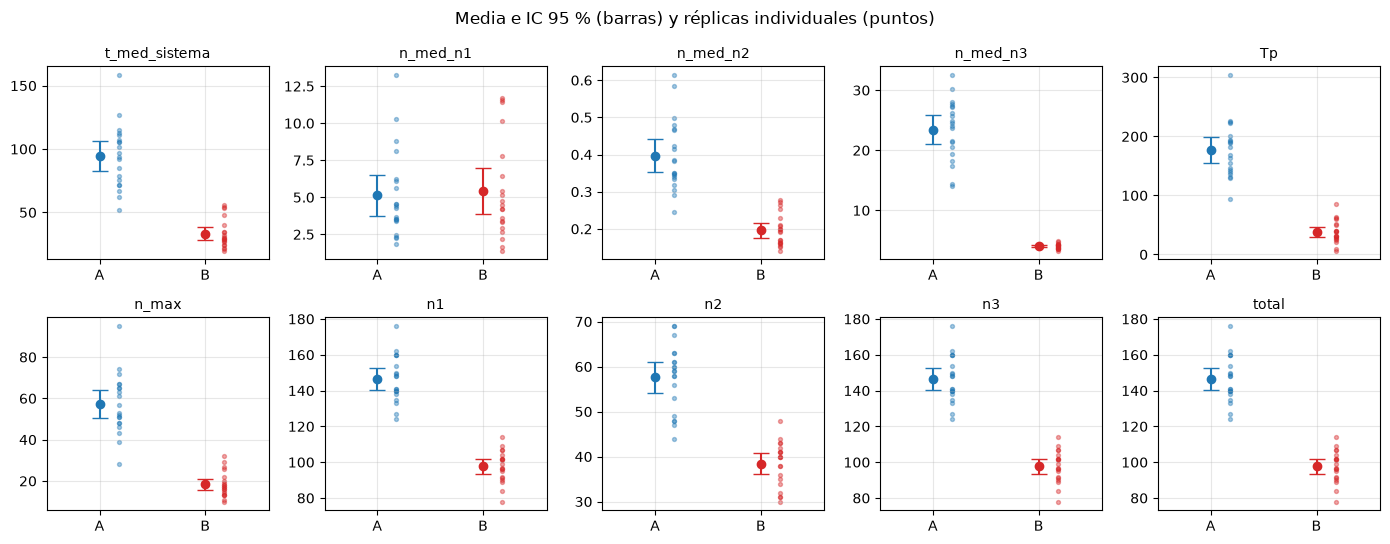

In [10]:
# Comparación visual de medias con sus IC al 95 %
claves = list(NOMBRES_RED)
fig, ejes = plt.subplots(2, 5, figsize=(14, 5.5))
for ax, clave in zip(ejes.ravel(), claves):
    for j, (esc, res) in enumerate(resumen_red.items()):
        f = res.loc[NOMBRES_RED[clave]]
        ax.errorbar(j, f['Media'], yerr=f['Semiancho'], fmt='o', capsize=6,
                    color=['tab:blue', 'tab:red'][j])
        ax.scatter(np.full(R_RED, j) + 0.18, replicas_red[esc][clave], s=8, alpha=0.4,
                   color=['tab:blue', 'tab:red'][j])
    ax.set_xticks([0, 1], ['A', 'B']); ax.set_xlim(-0.5, 1.6)
    ax.set_title(clave, fontsize=10)
fig.suptitle('Media e IC 95 % (barras) y réplicas individuales (puntos)')
fig.tight_layout()
fig.savefig(IMG_DIR / 'red_intervalos.png', bbox_inches='tight')
plt.show()

### Análisis (5.2)

**Carga de cada nodo.** Con tasa de llegada $\lambda=1/\text{media}$ y utilización $\rho_i=\lambda_i E[S_i]$:

| Nodo | Escenario A | Escenario B |
|---|---|---|
| 1 | $\lambda=0{,}5$, $E[S]=2{,}1$ → $\rho_1=1{,}05$ (levemente inestable) | $\lambda=0{,}333$, $E[S]\approx3{,}0$ → $\rho_1\approx1{,}0$ (crítico) |
| 2 | $\lambda_2=0{,}4\cdot0{,}476$ → $\rho_2\approx0{,}46$ | $\lambda_2=0{,}4\cdot0{,}333$ → $\rho_2=0{,}20$ |
| 3 | $\lambda_3\approx0{,}476$; $\rho_3=1{,}95$ si $n_3<5$ y $1{,}43$ si $n_3\ge5$ → **cuello de botella** | $\rho_3=1{,}33$ si $n_3<5$ y $0{,}67$ si $n_3\ge5$ → se autorregula |

**Media y desviación estándar muestral.**
- En **A**, el nodo 3 es inestable en cualquier estado: acumula en promedio 23,4 vehículos y la cola crece hasta el final. Por eso el tiempo medio en el sistema (94,6) y el tiempo de vaciado tras $T$ (176,6) son muy altos y tienen gran dispersión ($S=25{,}1$ y $46{,}7$).
- En **B**, el servicio del nodo 3 depende del estado. Con menos de 5 vehículos el nodo es lento ($\rho>1$) y la cola crece; con 5 o más se acelera ($\rho<1$) y la cola baja. Esto mantiene $n_3$ en torno a 4–5: $\bar n_3=4{,}03$ con $S=0{,}44$, la medida más estable de todo el estudio. El nodo 1 de B, en cambio, está en carga crítica y es muy variable ($\bar n_1=5{,}43$, $S=3{,}35$, réplicas entre 1,4 y 11,7).
- El nodo 2 está poco cargado en ambos escenarios ($\bar n_2=0{,}40$ y $0{,}20$). En B coincide con $\rho_2=0{,}2$.
- Los conteos validan el modelo: en toda réplica $n_1=n_3=$ total, porque todo vehículo pasa por los nodos 1 y 3, y $n_2/n_1=0{,}394$ (A) y $0{,}393$ (B), cerca de la probabilidad de enrutamiento 0,4.

**Intervalos de confianza al 95 %.**
- Los intervalos de los **conteos** son estrechos (semiancho ≈ 4 % de la media) y contienen el valor teórico $\lambda T$: 150 ∈ [140,2; 152,4] en A y 100 ∈ [93,6; 101,9] en B.
- Las medidas de **congestión** (tiempos, $\bar n_i$, $T_p$, $n_{max}$) tienen intervalos más anchos (semiancho relativo entre 10 % y 29 %). Los más anchos son los de nodos en carga crítica o inestable ($\bar n_1$ en A y B, $T_p$ en B). Para reducir el semiancho a la mitad se necesitarían unas $4\times20=80$ réplicas, porque el semiancho decrece como $1/\sqrt R$.
- Salvo $\bar n_1$, los intervalos de A y B **no se solapan** en ninguna medida: con 95 % de confianza, A es significativamente más congestionado. Para $\bar n_1$ los intervalos ([3,75; 6,52] frente a [3,87; 7,00]) se solapan casi por completo: no hay evidencia de diferencia en el nodo 1, lo que concuerda con $\rho_1\approx1$ en ambos.
- Como en 5.1, los sistemas inestables no tienen estado estacionario. Los intervalos estiman el desempeño medio en el horizonte $T=300$ partiendo de un sistema vacío, no un valor de largo plazo.

## 5.3. Inventario probabilístico

Modelo de la Sec. 5.6 de [Rios08]. Un almacén vende un producto a $r$ por unidad.

- **Clientes:** llegan según un proceso de Poisson de tasa $\lambda$. Cada uno demanda una cantidad aleatoria con distribución $G$. Si la demanda supera el inventario, se vende lo que queda y se pierde el resto de la venta.
- **Política de pedidos $(p,P)$:** cuando el nivel $x$ queda por debajo de $p$ y no hay pedido pendiente ($y=0$), se piden $P-x$ unidades, que llegan $L$ unidades de tiempo después y se pagan al llegar, a un costo $c(y)$.
- **Almacenamiento:** se paga un costo por unidad y por unidad de tiempo en inventario.

**Elementos del modelo de sucesos discretos**

| Elemento | Descripción |
|---|---|
| Variables de estado | $x$: unidades en inventario; $y$: unidades en el pedido pendiente ($y=0$: no hay) |
| Sucesos | Llegada de cliente ($t_C$) y llegada de pedido ($t_P$) |
| Contadores | $C$ costo de pedidos, $H$ costo de almacenamiento, $R$ ingresos por ventas, $N_{C+}$ / $N_{C-}$ clientes satisfechos / no satisfechos, $t_0$ tiempo con inventario en cero |
| Salidas | beneficio $=R-C-H$; %clientes satisfechos $=N_{C+}/(N_{C+}+N_{C-})$; %inventario en cero $=t_0/t$ |

**Parámetros.** Los de la guía son $P_0=20$, $P=100$, $p=20$, $L=5$, $h=100$ y $r=150$. La guía define $h$ como el *valor a pagar por una unidad del producto*, así que el costo de un pedido es $c(y)=h\,y$ y cada unidad vendida deja un margen de $r-h=50$. La guía no fija los demás parámetros; se eligen estos valores, todos modificables:

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| Horizonte $T$ | 100 días | Permite varios ciclos de pedido completos |
| $\lambda$ | 2 clientes/día | Demanda media de 6 unidades/día: en el tiempo de entrega $L=5$ se piden unas 30 unidades, más que el punto de pedido $p=20$, así que hay rupturas y el % en cero es informativo |
| $G$ | Uniforme discreta $\{1,\dots,5\}$ | Demanda media de 3 unidades por cliente |
| Costo de almacenamiento $a$ | 1 por unidad y día | 2 % del margen unitario, un valor de referencia |

Además, se analiza la sensibilidad a $\lambda$.

**Correcciones al pseudocódigo del libro.**
1. La condición de venta completa es `demanda ≤ x`, como dice el texto. El pseudocódigo usa `<`, que trataría como insatisfecho a un cliente que se lleva exactamente las últimas unidades.
2. El contador que aumenta en la venta completa es $N_{C+}$; el pseudocódigo tiene la errata $N_{C-}=N_{C+}+1$.
3. El inicio de un periodo en cero (`var_nivel0`) se registra cuando $x$ **pasa** a 0, sea por venta completa o parcial. El pseudocódigo lo reinicia con cada cliente insatisfecho, aunque el inventario ya estuviera vacío, y no lo registra cuando una venta completa agota el inventario. Ambas cosas subestiman $t_0$.

In [11]:
def simular_inventario(T, lam, gen_demanda, P0, P, p, L, h, a, r, rng):
    est = dict(t=0.0, x=P0, y=0, C=0.0, H=0.0, R=0.0, Nsat=0, Ninsat=0,
               t0=0.0, inicio_cero=None, tC=INF, tP=INF)
    traza = [(0.0, P0, 0, 0.0, 0.0, 0.0)]      # (t, x, y, H, C, R) tras cada suceso
    demandas = []                               # (t, demanda) de cada cliente

    def acumular_almacenamiento(t_suc):
        est['H'] += (t_suc - est['t']) * a * est['x']
        est['t'] = t_suc

    def llegada_cliente(t_suc):
        acumular_almacenamiento(t_suc)
        t, x = est['t'], est['x']
        d = gen_demanda(rng)
        demandas.append((t, d))
        if d <= x:                              # venta completa
            est['R'] += d * r
            est['x'] = x - d
            est['Nsat'] += 1
        else:                                   # se vende lo que queda
            est['R'] += x * r
            est['x'] = 0
            est['Ninsat'] += 1
        if est['x'] == 0 and est['inicio_cero'] is None:
            est['inicio_cero'] = t              # el inventario acaba de llegar a cero
        if est['x'] < p and est['y'] == 0:      # política de pedidos
            est['y'] = P - est['x']
            est['tP'] = t + L
        Y = rng.exponential(1 / lam)
        est['tC'] = t + Y if t + Y < T else INF

    def llegada_pedido(t_suc):
        acumular_almacenamiento(t_suc)
        est['C'] += h * est['y']                # c(y) = h·y
        est['x'] += est['y']
        est['y'] = 0
        if est['inicio_cero'] is not None:      # termina un periodo sin inventario
            est['t0'] += est['t'] - est['inicio_cero']
            est['inicio_cero'] = None

    Z = rng.exponential(1 / lam)
    if Z < T:
        llegada_cliente(Z)
        traza.append((est['t'], est['x'], est['y'], est['H'], est['C'], est['R']))
        while est['tC'] < INF or est['tP'] < INF:
            if est['tC'] <= est['tP']:
                t_suc, est['tC'] = est['tC'], INF
                llegada_cliente(t_suc)
            else:
                t_suc, est['tP'] = est['tP'], INF
                llegada_pedido(t_suc)
            traza.append((est['t'], est['x'], est['y'], est['H'], est['C'], est['R']))

    n_clientes = est['Nsat'] + est['Ninsat']
    medidas = {
        'beneficio': est['R'] - est['C'] - est['H'],
        'pct_satisf': 100 * est['Nsat'] / n_clientes if n_clientes else 0.0,
        'pct_inv0': 100 * est['t0'] / est['t'] if est['t'] > 0 else 0.0,
        'R': est['R'], 'C': est['C'], 'H': est['H'],
        'clientes': n_clientes, 't_fin': est['t'], 'x_fin': est['x'],
        # Medida auxiliar: beneficio sumando el inventario final valorado a costo h
        'beneficio_aj': est['R'] - est['C'] - est['H'] + h * est['x'],
    }
    return medidas, np.array(traza), np.array(demandas)

PARAM_INV = dict(T=100.0, lam=2.0, gen_demanda=lambda rng: int(rng.integers(1, 6)),
                 P0=20, P=100, p=20, L=5.0, h=100.0, a=1.0, r=150.0)

### Corrida base y evolución temporal (equivalente a la Figura 5.9 del libro)

Clientes atendidos: 193   |   fin de la simulación: t = 101.49
Ingresos por ventas R = 77,250
Costo de pedidos    C = 57,600
Costo almacenamiento H = 3,433
Beneficio = R - C - H = 16,217
Porcentaje de clientes satisfechos: 89.64 %
Porcentaje de tiempo con inventario en cero: 13.30 %
Inventario final: 81 unidades -> beneficio + h·x_fin = 24,317


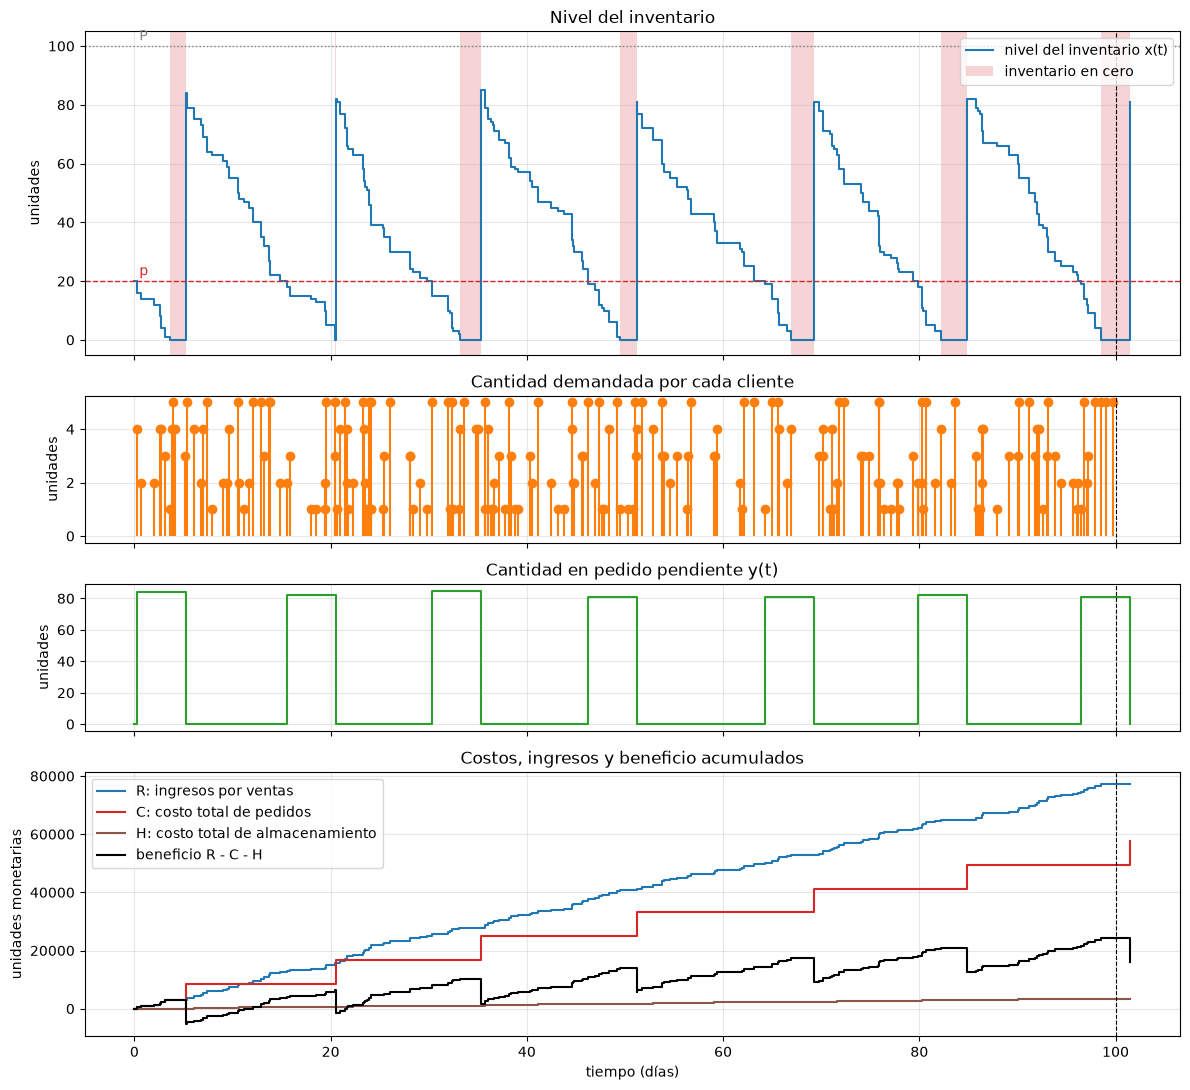

In [12]:
rng = np.random.default_rng(SEMILLA_BASE + 9000)
m_inv, tr_inv, dem_inv = simular_inventario(rng=rng, **PARAM_INV)

print(f"Clientes atendidos: {m_inv['clientes']}   |   fin de la simulación: t = {m_inv['t_fin']:.2f}")
print(f"Ingresos por ventas R = {m_inv['R']:,.0f}")
print(f"Costo de pedidos    C = {m_inv['C']:,.0f}")
print(f"Costo almacenamiento H = {m_inv['H']:,.0f}")
print(f"Beneficio = R - C - H = {m_inv['beneficio']:,.0f}")
print(f"Porcentaje de clientes satisfechos: {m_inv['pct_satisf']:.2f} %")
print(f"Porcentaje de tiempo con inventario en cero: {m_inv['pct_inv0']:.2f} %")
print(f"Inventario final: {m_inv['x_fin']} unidades -> beneficio + h·x_fin = {m_inv['beneficio_aj']:,.0f}")

t_ev, x_ev, y_ev, H_ev, C_ev, R_ev = tr_inv.T
T_inv, p_inv, P_inv = PARAM_INV['T'], PARAM_INV['p'], PARAM_INV['P']
fig, ejes = plt.subplots(4, 1, figsize=(12, 11), sharex=True,
                         gridspec_kw={'height_ratios': [2.2, 1, 1, 1.8]})
ax = ejes[0]
ax.step(t_ev, x_ev, where='post', color='tab:blue', label='nivel del inventario x(t)')
ax.axhline(P_inv, color='gray', ls=':', lw=1); ax.text(0.5, P_inv + 2, 'P', color='gray')
ax.axhline(p_inv, color='tab:red', ls='--', lw=1); ax.text(0.5, p_inv + 2, 'p', color='tab:red')
for k in np.flatnonzero(x_ev[:-1] == 0):     # periodos con inventario en cero
    ax.axvspan(t_ev[k], t_ev[k + 1], color='tab:red', alpha=0.2, lw=0,
               label='inventario en cero' if k == np.flatnonzero(x_ev[:-1] == 0)[0] else None)
ax.set_ylabel('unidades'); ax.legend(loc='upper right'); ax.set_title('Nivel del inventario')
ax = ejes[1]
ax.stem(dem_inv[:, 0], dem_inv[:, 1], linefmt='tab:orange', markerfmt='o', basefmt=' ')
ax.set_ylabel('unidades'); ax.set_title('Cantidad demandada por cada cliente')
ax = ejes[2]
ax.step(t_ev, y_ev, where='post', color='tab:green')
ax.set_ylabel('unidades'); ax.set_title('Cantidad en pedido pendiente y(t)')
ax = ejes[3]
ax.step(t_ev, R_ev, where='post', label='R: ingresos por ventas', color='tab:blue')
ax.step(t_ev, C_ev, where='post', label='C: costo total de pedidos', color='tab:red')
ax.step(t_ev, H_ev, where='post', label='H: costo total de almacenamiento', color='tab:brown')
ax.step(t_ev, R_ev - C_ev - H_ev, where='post', label='beneficio R - C - H', color='k', lw=1.5)
ax.set_ylabel('unidades monetarias'); ax.set_xlabel('tiempo (días)')
ax.set_title('Costos, ingresos y beneficio acumulados'); ax.legend(loc='upper left')
for ax in ejes:
    ax.axvline(T_inv, color='k', ls='--', lw=0.8)
fig.tight_layout()
fig.savefig(IMG_DIR / 'inventario_evolucion.png', bbox_inches='tight')
plt.show()

### 20 réplicas de la configuración base

Siguiendo la recomendación del libro, se replica la simulación para estimar las medidas con su incertidumbre.

In [13]:
R_INV = 20
filas = []
for i in range(R_INV):
    rng = np.random.default_rng(SEMILLA_BASE + 9000 + i)
    m, _, _ = simular_inventario(rng=rng, **PARAM_INV)
    filas.append(m)
replicas_inv = pd.DataFrame(filas, index=pd.RangeIndex(1, R_INV + 1, name='réplica'))
replicas_inv.to_csv(DAT_DIR / 'inventario_replicas.csv')
display(replicas_inv)

NOMBRES_INV = {'beneficio': 'Beneficio', 'pct_satisf': 'Porcentaje de clientes satisfechos (\\%)',
               'pct_inv0': 'Porcentaje de tiempo con inventario en cero (\\%)'}
NOMBRES_INV_TABLA = {**NOMBRES_INV,
                     'beneficio_aj': 'Beneficio + valor del inventario final ($h\\,x_{fin}$)'}
filas, lineas = [], []
for clave, nombre in NOMBRES_INV_TABLA.items():
    media, s, li, ls = resumen(replicas_inv[clave])
    filas.append({'Medida': nombre.replace('\\%', '%'), 'Media': media, 'Desv. estándar': s,
                  'IC95 inf': li, 'IC95 sup': ls})
    dec = 0 if clave.startswith('beneficio') else 2
    lineas.append(f"{nombre} & {num(media, dec)} & {num(s, dec)} & [{num(li, dec)};\\ {num(ls, dec)}] \\\\")
display(pd.DataFrame(filas).set_index('Medida'))
_ = (TAB_DIR / 'tabla_inventario.tex').write_text('\n'.join(lineas), encoding='utf-8')

,beneficio,pct_satisf,pct_inv0,R,C,H,clientes,t_fin,x_fin,beneficio_aj
réplica,,,,,,,,,,
1,16216.5454,89.6373,13.3022,77250.0000,57600.0000,3433.4546,193,101.4919,81,24316.5454
2,24637.1733,92.0398,11.4998,85650.0000,57500.0000,3512.8267,201,99.7625,24,27037.1733
3,15378.7896,85.7143,13.7748,76350.0000,57500.0000,3471.2104,203,103.5795,86,23978.7896
4,12734.2692,69.8020,18.4626,65850.0000,49300.0000,3815.7308,202,99.5378,74,20134.2692
5,24241.2834,84.1410,15.6888,85650.0000,57800.0000,3608.7166,227,99.6477,27,26941.2834
6,12581.3520,85.2792,11.6656,73800.0000,57200.0000,4018.6480,197,104.0530,100,22581.3520
7,20114.8238,90.3670,13.9024,89250.0000,65700.0000,3435.1762,218,101.7499,82,28314.8238
8,24137.2418,84.8780,8.5988,85050.0000,57600.0000,3312.7582,205,98.7897,29,27037.2418
9,19435.9093,84.7826,12.7795,72300.0000,49000.0000,3864.0907,184,99.7931,28,22235.9093


,Media,Desv. estándar,IC95 inf,IC95 sup
Medida,,,,
Beneficio,17717.6770,3742.8267,15965.9802,19469.3738
Porcentaje de clientes satisfechos (%),85.6036,4.7658,83.3732,87.8341
Porcentaje de tiempo con inventario en cero (%),12.3915,2.9966,10.9891,13.7940
"Beneficio + valor del inventario final ($h\,x_{fin}$)",24257.6770,2282.9979,23189.2011,25326.1529


### Sensibilidad a la tasa de llegada $\lambda$

Como la guía deja $\lambda$ libre, se repite el experimento (20 réplicas) con $\lambda\in\{1;\,1{,}5;\,2;\,2{,}5;\,3\}$, manteniendo la misma política $(p,P)=(20,100)$.

,demanda media/día,demanda en L,beneficio,beneficio_h,pct_satisf,pct_satisf_h,pct_inv0,pct_inv0_h
lambda,,,,,,,,
1.0000,3.0000,15.0000,5658.3955,1092.8256,98.0436,0.9540,1.2986,0.8195
1.5000,4.5000,22.5000,12094.1681,1490.1836,92.5788,1.6639,5.3977,1.2656
2.0000,6.0000,30.0000,17717.6770,1751.6968,85.6036,2.2304,12.3915,1.4024
2.5000,7.5000,37.5000,21456.2433,936.3473,79.0091,1.1354,19.7471,1.2371
3.0000,9.0000,45.0000,25923.2049,1247.4450,74.2387,1.6210,23.7322,1.5791


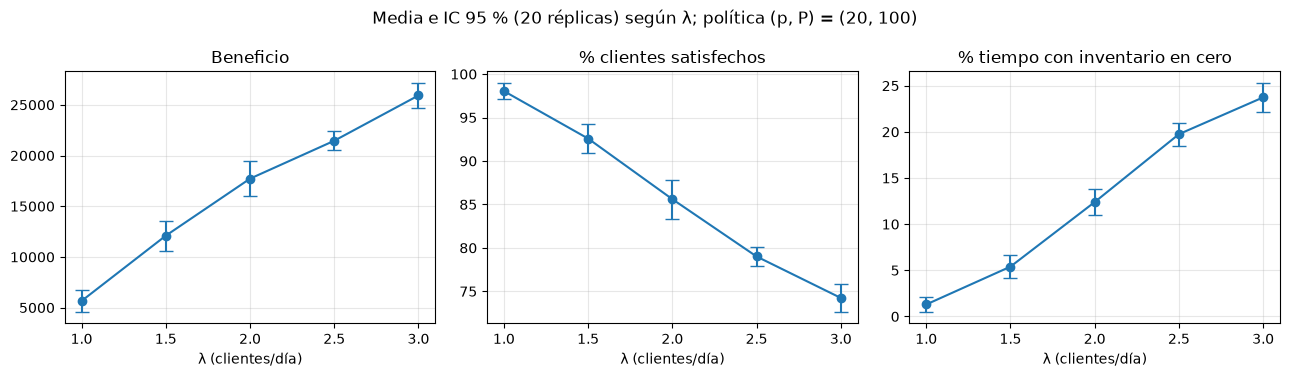

In [14]:
LAMBDAS = [1.0, 1.5, 2.0, 2.5, 3.0]
filas = []
for lam in LAMBDAS:
    ms = []
    for i in range(R_INV):
        rng = np.random.default_rng(SEMILLA_BASE + 9000 + i)
        m, _, _ = simular_inventario(rng=rng, **{**PARAM_INV, 'lam': lam})
        ms.append(m)
    df = pd.DataFrame(ms)
    fila = {'lambda': lam, 'demanda media/día': 3 * lam, 'demanda en L': 3 * lam * PARAM_INV['L']}
    for clave in NOMBRES_INV:
        media, s, li, ls = resumen(df[clave])
        fila[clave] = media
        fila[clave + '_h'] = (ls - li) / 2
    filas.append(fila)
sens_inv = pd.DataFrame(filas).set_index('lambda')
display(sens_inv)

lineas = []
for lam, f in sens_inv.iterrows():
    lineas.append(f"{num(lam, 1)} & {num(f['demanda en L'], 1)} & "
                  f"${num(f['beneficio'], 0)} \\pm {num(f['beneficio_h'], 0)}$ & "
                  f"${num(f['pct_satisf'], 1)} \\pm {num(f['pct_satisf_h'], 1)}$ & "
                  f"${num(f['pct_inv0'], 1)} \\pm {num(f['pct_inv0_h'], 1)}$ \\\\")
_ = (TAB_DIR / 'tabla_inventario_lambda.tex').write_text('\n'.join(lineas), encoding='utf-8')

fig, ejes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (clave, titulo) in zip(ejes, [('beneficio', 'Beneficio'), ('pct_satisf', '% clientes satisfechos'),
                                     ('pct_inv0', '% tiempo con inventario en cero')]):
    ax.errorbar(sens_inv.index, sens_inv[clave], yerr=sens_inv[clave + '_h'], fmt='o-', capsize=5)
    ax.set_xlabel('λ (clientes/día)'); ax.set_title(titulo)
fig.suptitle('Media e IC 95 % (20 réplicas) según λ; política (p, P) = (20, 100)')
fig.tight_layout()
fig.savefig(IMG_DIR / 'inventario_sensibilidad.png', bbox_inches='tight')
plt.show()

### Complemento: efecto del punto de pedido $p$ ($\lambda=2$)

La demanda durante el tiempo de entrega es Poisson compuesta: tiene media $\lambda L\,E[D]=30$ y varianza $\lambda L\,E[D^2]=10\cdot11=110$, es decir, $\sigma\approx10{,}5$. Con $p=20$ el punto de pedido queda por debajo de la demanda esperada en $L$, lo que explica las rupturas. Para comprobarlo se prueban varios valores de $p$ con las mismas 20 semillas.

In [15]:
filas = []
for p_alt in [20, 30, 40, 50]:
    ms = []
    for i in range(R_INV):
        rng = np.random.default_rng(SEMILLA_BASE + 9000 + i)
        m, _, _ = simular_inventario(rng=rng, **{**PARAM_INV, 'p': p_alt})
        ms.append(m)
    df = pd.DataFrame(ms)
    filas.append({'p': p_alt, 'beneficio': df['beneficio'].mean(), 'beneficio_aj': df['beneficio_aj'].mean(),
                  'H': df['H'].mean(), 'pct_satisf': df['pct_satisf'].mean(), 'pct_inv0': df['pct_inv0'].mean()})
sens_p = pd.DataFrame(filas).set_index('p')
display(sens_p)
lineas = [f"{p_alt} & {num(f['beneficio'], 0)} & {num(f['beneficio_aj'], 0)} & {num(f['H'], 0)} & "
          f"{num(f['pct_satisf'], 1)} & {num(f['pct_inv0'], 1)} \\\\" for p_alt, f in sens_p.iterrows()]
_ = (TAB_DIR / 'tabla_inventario_p.tex').write_text('\n'.join(lineas), encoding='utf-8')

,beneficio,beneficio_aj,H,pct_satisf,pct_inv0
p,,,,,
20,17717.6770,24257.6770,3647.3230,85.6036,12.3915
30,19332.2424,25617.2424,3792.7576,90.9398,7.2306
40,19579.9337,26644.9337,4072.5663,95.5050,3.4930
50,20054.0322,26799.0322,4468.4678,97.4498,2.0031


### Análisis (5.3)

**Evolución temporal.** El nivel del inventario sigue el patrón de diente de sierra de la Figura 5.9 del libro:
- Cuando $x$ baja de $p=20$ se pide $P-x\approx80$–$85$ unidades, y el nivel sube al llegar el pedido.
- El inventario nunca alcanza $P=100$, porque durante los $L=5$ días de entrega sigue habiendo ventas.
- Hay una ruptura (tramos sombreados) en casi todos los ciclos: la demanda esperada durante la entrega ($\lambda L\,E[D]=30$ unidades) supera el punto de pedido.
- El costo de pedidos $C$ crece en escalones de unos 8 000 (80 unidades × $h$), los ingresos $R$ crecen de forma casi continua y el costo de almacenamiento $H$ es pequeño: ≈3 650, un 4,5 % de $R$.

**Medidas de desempeño (20 réplicas, $\lambda=2$).**
- Beneficio medio: 17 718, con IC 95 % [15 966; 19 469].
- Clientes satisfechos: 85,6 %, con IC [83,4; 87,8].
- Tiempo con inventario en cero: 12,4 %, con IC [11,0; 13,8].

Los porcentajes se estiman con precisión (semiancho de ±2,2 y ±1,4 puntos). El beneficio es más incierto (±9,9 %), sobre todo por un **efecto de borde**: la política sigue pidiendo cerca del final, y el último pedido se paga completo aunque sus unidades ya no se venden dentro del horizonte. En la corrida base, el pedido que llega en $t=101{,}5$ reduce el beneficio de ≈24 300 a 16 217. La correlación entre el beneficio y el inventario final es de −0,80. Si se suma el inventario final valorado a su costo ($h\,x_{fin}$), el beneficio medio sube a 24 258 y su desviación estándar baja de 3 743 a 2 283.

**Sensibilidad a $\lambda$.** Al aumentar la tasa de llegadas de 1 a 3 clientes/día:
- El beneficio crece casi linealmente (de 5 658 a 25 923), porque cada unidad vendida deja un margen positivo $r-h=50$.
- El nivel de servicio cae de 98,0 % a 74,2 % y el tiempo sin inventario sube de 1,3 % a 23,7 %.

La política $(20,100)$ solo es adecuada cuando la demanda durante la entrega es menor que $p$ ($\lambda=1$: 15 unidades). Con $\lambda\ge1{,}5$, esa demanda (22,5 a 45) supera el punto de pedido y las rupturas se vuelven sistemáticas.

**Punto de pedido.** Con $\lambda=2$, subir $p$ a 40 ($\approx\mu_L+1\sigma_L$) eleva el servicio a 95,5 % y reduce el tiempo en cero a 3,5 %. El beneficio también sube (19 580; 26 645 ajustado), a cambio de un 12 % más de costo de almacenamiento. Con $p=50$ la mejora adicional es pequeña (97,4 %). Esta es la información que el empresario usaría para redefinir su política, como plantea el libro.

## 5.4. Simulación de eventos discretos con SimPy

SimPy es un framework de simulación de eventos discretos **orientado a procesos**. Cada entidad (cliente, máquina, vehículo) es una función generadora de Python que suspende su ejecución con `yield` sobre un evento: un `timeout`, la solicitud de un recurso, otro proceso o una condición. El `Environment` guarda la lista de eventos futuros ordenada por tiempo y avanza el reloj de un evento al siguiente.

A diferencia de 5.1 y 5.2, donde se programan a mano la lista de sucesos y las rutinas de cada suceso, en SimPy se describe el *ciclo de vida* de cada entidad y el framework resuelve la planificación.

In [16]:
import random
import itertools
import simpy
print('SimPy', simpy.__version__)

SimPy 4.1.2


### 5.4.1. Tutoriales

#### a) Funciones generadoras (base de los procesos SimPy)
`yield` suspende la función y devuelve un valor; `send()` la reanuda inyectando un valor.

In [17]:
def generador(x):
    y = yield x + 1
    return y + 1

g = generador(3)
print('next(g) ->', next(g))

def duplicar():
    while True:
        x = yield
        yield x * 2

gen = duplicar()
next(gen)                     # avanza hasta el primer yield
for valor in (5, 6, 94.3):
    print(f'send({valor}) ->', gen.send(valor))
    next(gen)

next(g) -> 4
send(5) -> 10
send(6) -> 12
send(94.3) -> 188.6


#### b) Procesos y `timeout`: relojes con distinto paso
Los tres procesos avanzan en paralelo sobre un mismo reloj simulado; los eventos simultáneos se atienden en orden de programación.

In [18]:
def reloj(env, nombre, paso):
    while True:
        print(f'{nombre:>8s} t={env.now:.2f}')
        yield env.timeout(paso)

env = simpy.Environment()
env.process(reloj(env, 'rápido', 0.5))
env.process(reloj(env, 'lento', 1))
env.run(until=3)

  rápido t=0.00
   lento t=0.00
  rápido t=0.50
   lento t=1.00
  rápido t=1.00
  rápido t=1.50
   lento t=2.00
  rápido t=2.00
  rápido t=2.50


#### c) *SimPy in 10 minutes*: un proceso con dos estados (estacionar / conducir)

In [19]:
def carro(env):
    while True:
        print(f'Empieza a estacionar en {env.now}')
        yield env.timeout(5)          # duración del estacionamiento
        print(f'Empieza a conducir en {env.now}')
        yield env.timeout(2)          # duración del viaje

env = simpy.Environment()
env.process(carro(env))
env.run(until=15)

Empieza a estacionar en 0
Empieza a conducir en 5
Empieza a estacionar en 7
Empieza a conducir en 12
Empieza a estacionar en 14


#### d) Interacción entre procesos: esperar otro proceso e interrumpirlo
Un proceso puede esperar a que termine otro (`yield env.process(...)`) y también puede interrumpirlo (`proc.interrupt()`). Aquí el conductor interrumpe la carga de la batería a los 3 minutos.

In [20]:
class CarroElectrico:
    def __init__(self, env):
        self.env = env
        self.accion = env.process(self.correr())

    def correr(self):
        while True:
            print(f'Estaciona y carga en {self.env.now}')
            try:
                yield self.env.process(self.cargar(5))
            except simpy.Interrupt:
                print(f'Interrupción en {self.env.now}: ¡la batería está suficientemente cargada!')
            print(f'Empieza a conducir en {self.env.now}')
            yield self.env.timeout(2)

    def cargar(self, duracion):
        yield self.env.timeout(duracion)

def conductor(env, carro):
    yield env.timeout(3)
    carro.accion.interrupt()

env = simpy.Environment()
c = CarroElectrico(env)
env.process(conductor(env, c))
env.run(until=15)

Estaciona y carga en 0
Interrupción en 3: ¡la batería está suficientemente cargada!
Empieza a conducir en 3
Estaciona y carga en 5
Empieza a conducir en 10
Estaciona y carga en 12


#### e) Recursos compartidos: estación de carga con 2 puntos
`simpy.Resource` modela un servidor con capacidad limitada y cola FIFO. `with recurso.request() as req: yield req` espera turno y libera el recurso al salir del bloque.

In [21]:
def carro_bcs(env, nombre, bcs, t_conduccion, t_carga):
    yield env.timeout(t_conduccion)
    print(f'{nombre} llega a la estación en {env.now}')
    with bcs.request() as req:
        yield req
        print(f'{nombre} empieza a cargar en {env.now}')
        yield env.timeout(t_carga)
        print(f'{nombre} sale de la estación en {env.now}')

env = simpy.Environment()
bcs = simpy.Resource(env, capacity=2)
for i in range(4):
    env.process(carro_bcs(env, f'Carro {i}', bcs, i * 2, 5))
env.run()

Carro 0 llega a la estación en 0
Carro 0 empieza a cargar en 0
Carro 1 llega a la estación en 2
Carro 1 empieza a cargar en 2
Carro 2 llega a la estación en 4
Carro 0 sale de la estación en 5
Carro 2 empieza a cargar en 5
Carro 3 llega a la estación en 6
Carro 1 sale de la estación en 7
Carro 3 empieza a cargar en 7
Carro 2 sale de la estación en 10
Carro 3 sale de la estación en 12


#### f) Condiciones e interrupciones: moderador y orador (notebook *Discrete-event simulation with SimPy*)
`yield a | b` espera al **primero** de dos eventos. El moderador concede 30 minutos: si la charla dura más, interrumpe al orador.

In [22]:
random.seed(160005010)

def orador(env, i):
    try:
        duracion = random.randint(25, 35)
        print(f'  orador {i} inicia en {env.now} (duración planeada {duracion})')
        yield env.timeout(duracion)
        print(f'  orador {i} termina a tiempo en {env.now}')
    except simpy.Interrupt as interr:
        print(f'  orador {i} interrumpido en {env.now}: {interr.cause}')

def moderador(env, n_charlas):
    for i in range(n_charlas):
        proc = env.process(orador(env, i))
        limite = env.timeout(30)
        resultado = yield proc | limite
        if limite in resultado and not proc.triggered:
            proc.interrupt('¡Se acabó el tiempo!')
            yield proc

env = simpy.Environment()
env.process(moderador(env, 5))
env.run()

  orador 0 inicia en 0 (duración planeada 35)
  orador 0 interrumpido en 30: ¡Se acabó el tiempo!
  orador 1 inicia en 30 (duración planeada 30)
  orador 1 termina a tiempo en 60
  orador 2 inicia en 60 (duración planeada 32)
  orador 2 interrumpido en 90: ¡Se acabó el tiempo!
  orador 3 inicia en 90 (duración planeada 31)
  orador 3 interrumpido en 120: ¡Se acabó el tiempo!
  orador 4 inicia en 120 (duración planeada 32)
  orador 4 interrumpido en 150: ¡Se acabó el tiempo!


#### g) Asistentes a una conferencia con buffet de capacidad limitada
Combina un `Resource` (3 puestos del buffet) con una condición: cada asistente espera un puesto **o** el fin del receso, lo que ocurra primero. Si consigue puesto con poco tiempo, come menos.

In [23]:
random.seed(160005010)
CHARLAS_POR_SESION, DURACION_CHARLA, DURACION_RECESO, TIEMPO_COMER, PUESTOS_BUFFET = 4, 30, 5, 2, 3

def asistente(env, nombre, buffet, conocimiento=0, hambre=0):
    while True:
        for _ in range(CHARLAS_POR_SESION):
            conocimiento += random.randint(0, 3) / (1 + hambre)
            hambre += random.randint(1, 4)
            yield env.timeout(DURACION_CHARLA)
        print(f'{env.now:5.0f}: asistente {nombre} termina charlas (conocimiento {conocimiento:.2f}, hambre {hambre})')
        inicio = env.now
        with buffet.request() as req:
            yield req | env.timeout(DURACION_RECESO - TIEMPO_COMER)
            tiempo_restante = DURACION_RECESO - (env.now - inicio)
            if req.triggered:
                comida = min(random.randint(3, 12), tiempo_restante)
                yield env.timeout(TIEMPO_COMER)
                hambre -= min(comida, hambre)
                print(f'{env.now:5.0f}: asistente {nombre} comió; hambre {hambre}')
            else:
                print(f'{env.now:5.0f}: asistente {nombre} no alcanzó a comer')
        yield env.timeout(max(0, DURACION_RECESO - (env.now - inicio)))

env = simpy.Environment()
buffet = simpy.Resource(env, capacity=PUESTOS_BUFFET)
for i in range(7):
    env.process(asistente(env, i, buffet))
env.run(until=130)

  120: asistente 0 termina charlas (conocimiento 2.00, hambre 11)
  120: asistente 1 termina charlas (conocimiento 3.79, hambre 13)
  120: asistente 2 termina charlas (conocimiento 1.48, hambre 7)
  120: asistente 3 termina charlas (conocimiento 2.31, hambre 8)
  120: asistente 4 termina charlas (conocimiento 0.41, hambre 13)
  120: asistente 5 termina charlas (conocimiento 4.35, hambre 8)
  120: asistente 6 termina charlas (conocimiento 2.32, hambre 7)
  122: asistente 0 comió; hambre 6
  122: asistente 1 comió; hambre 8
  122: asistente 2 comió; hambre 2
  123: asistente 6 no alcanzó a comer
  124: asistente 3 comió; hambre 5
  124: asistente 4 comió; hambre 10
  124: asistente 5 comió; hambre 5


### 5.4.2. Ejemplos oficiales de SimPy

Se implementan los siete ejemplos de la documentación de SimPy. Se conserva la lógica y la semilla original (`RANDOM_SEED = 42`), así que las salidas pueden contrastarse con las publicadas en la documentación. Mensajes y comentarios se traducen al español.

#### Ejemplo 1: Bank Renege (abandono en un banco)
**Cubre:** `Resource` y eventos de condición.
**Escenario:** un cajero con tiempo de servicio exponencial (media 12). Cada cliente tiene una paciencia $\sim U(1,3)$: espera el cajero **o** a que se agote su paciencia (`req | timeout(paciencia)`), y si lo segundo ocurre primero, abandona la cola (*renege*).

In [24]:
RANDOM_SEED = 42
NEW_CUSTOMERS = 5          # número total de clientes
INTERVAL_CUSTOMERS = 10.0  # se genera un cliente cada ~x segundos
MIN_PATIENCE = 1           # paciencia mínima
MAX_PATIENCE = 3           # paciencia máxima

def source(env, number, interval, counter):
    # Genera clientes aleatoriamente
    for i in range(number):
        c = customer(env, f'Cliente{i:02d}', counter, time_in_bank=12.0)
        env.process(c)
        t = random.expovariate(1.0 / interval)
        yield env.timeout(t)

def customer(env, name, counter, time_in_bank):
    # El cliente llega, es atendido y se va (o abandona)
    arrive = env.now
    print(f'{arrive:7.4f} {name}: llega')
    with counter.request() as req:
        patience = random.uniform(MIN_PATIENCE, MAX_PATIENCE)
        # Espera el cajero o se rinde al agotar la paciencia
        results = yield req | env.timeout(patience)
        wait = env.now - arrive
        if req in results:
            print(f'{env.now:7.4f} {name}: esperó {wait:6.3f}')
            tib = random.expovariate(1.0 / time_in_bank)
            yield env.timeout(tib)
            print(f'{env.now:7.4f} {name}: terminó')
        else:
            print(f'{env.now:7.4f} {name}: ABANDONÓ tras {wait:6.3f}')

print('Bank renege')
random.seed(RANDOM_SEED)
env = simpy.Environment()
counter = simpy.Resource(env, capacity=1)
env.process(source(env, NEW_CUSTOMERS, INTERVAL_CUSTOMERS, counter))
env.run()

Bank renege
 0.0000 Cliente00: llega
 0.0000 Cliente00: esperó  0.000
 3.8595 Cliente00: terminó
10.2006 Cliente01: llega
10.2006 Cliente01: esperó  0.000
12.7265 Cliente02: llega
13.9003 Cliente02: ABANDONÓ tras  1.174
23.7507 Cliente01: terminó
34.9993 Cliente03: llega
34.9993 Cliente03: esperó  0.000
37.9599 Cliente03: terminó
40.4798 Cliente04: llega
40.4798 Cliente04: esperó  0.000
43.1401 Cliente04: terminó


#### Ejemplo 2: Carwash (autolavado)
**Cubre:** esperar a otros procesos y `Resource`.
**Escenario:** un autolavado con 2 máquinas y lavado de 5 min. Hay 4 carros al inicio y luego llega uno cada $U\{5,\dots,9\}$ min; si no hay máquina libre, el carro espera.

In [25]:
RANDOM_SEED = 42
NUM_MACHINES = 2  # máquinas de lavado
WASHTIME = 5      # minutos por lavado
T_INTER = 7       # un carro cada ~7 minutos
SIM_TIME = 20     # minutos simulados

class Carwash:
    def __init__(self, env, num_machines, washtime):
        self.env = env
        self.machine = simpy.Resource(env, num_machines)
        self.washtime = washtime

    def wash(self, car):
        yield self.env.timeout(self.washtime)
        pct_dirt = random.randint(50, 99)
        print(f'El autolavado removió el {pct_dirt}% de la suciedad de {car}.')

def car(env, name, cw):
    print(f'{name} llega al autolavado en {env.now:.2f}.')
    with cw.machine.request() as request:
        yield request
        print(f'{name} entra al autolavado en {env.now:.2f}.')
        yield env.process(cw.wash(name))
        print(f'{name} sale del autolavado en {env.now:.2f}.')

def setup(env, num_machines, washtime, t_inter):
    carwash = Carwash(env, num_machines, washtime)
    car_count = itertools.count()
    for _ in range(4):                       # 4 carros iniciales
        env.process(car(env, f'Carro {next(car_count)}', carwash))
    while True:                              # llegadas durante la simulación
        yield env.timeout(random.randint(t_inter - 2, t_inter + 2))
        env.process(car(env, f'Carro {next(car_count)}', carwash))

print('Carwash')
random.seed(RANDOM_SEED)
env = simpy.Environment()
env.process(setup(env, NUM_MACHINES, WASHTIME, T_INTER))
env.run(until=SIM_TIME)

Carwash
Carro 0 llega al autolavado en 0.00.
Carro 1 llega al autolavado en 0.00.
Carro 2 llega al autolavado en 0.00.
Carro 3 llega al autolavado en 0.00.
Carro 0 entra al autolavado en 0.00.
Carro 1 entra al autolavado en 0.00.
Carro 4 llega al autolavado en 5.00.
El autolavado removió el 97% de la suciedad de Carro 0.
El autolavado removió el 67% de la suciedad de Carro 1.
Carro 0 sale del autolavado en 5.00.
Carro 1 sale del autolavado en 5.00.
Carro 2 entra al autolavado en 5.00.
Carro 3 entra al autolavado en 5.00.
Carro 5 llega al autolavado en 10.00.
El autolavado removió el 64% de la suciedad de Carro 2.
El autolavado removió el 58% de la suciedad de Carro 3.
Carro 2 sale del autolavado en 10.00.
Carro 3 sale del autolavado en 10.00.
Carro 4 entra al autolavado en 10.00.
Carro 5 entra al autolavado en 10.00.
El autolavado removió el 97% de la suciedad de Carro 4.
El autolavado removió el 56% de la suciedad de Carro 5.
Carro 4 sale del autolavado en 15.00.
Carro 5 sale del auto

#### Ejemplo 3: Machine Shop (taller de máquinas)
**Cubre:** interrupciones y `PreemptiveResource`.
**Escenario:** 10 máquinas producen piezas con tiempo $N(10,2)$ min y se averían con tiempo entre fallas exponencial (MTTF 300 min). Un único técnico las repara (30 min). Cuando no hay reparaciones, el técnico hace otros trabajos de menor prioridad, que las averías **interrumpen** (prioridad 1 frente a 2). Se simulan 4 semanas.

In [26]:
RANDOM_SEED = 42
PT_MEAN = 10.0          # tiempo medio de procesamiento (min)
PT_SIGMA = 2.0          # desviación del tiempo de procesamiento
MTTF = 300.0            # tiempo medio hasta la falla (min)
BREAK_MEAN = 1 / MTTF   # parámetro de expovariate
REPAIR_TIME = 30.0      # tiempo de reparación (min)
JOB_DURATION = 30.0     # duración de otros trabajos (min)
NUM_MACHINES = 10       # número de máquinas
WEEKS = 4               # semanas simuladas
SIM_TIME = WEEKS * 7 * 24 * 60

def time_per_part():
    # Tiempo de procesamiento de una pieza (se descartan valores no positivos)
    t = random.normalvariate(PT_MEAN, PT_SIGMA)
    while t <= 0:
        t = random.normalvariate(PT_MEAN, PT_SIGMA)
    return t

def time_to_failure():
    return random.expovariate(BREAK_MEAN)

class Machine:
    def __init__(self, env, name, repairman):
        self.env = env
        self.name = name
        self.parts_made = 0
        self.broken = False
        self.process = env.process(self.working(repairman))
        env.process(self.break_machine())

    def working(self, repairman):
        while True:
            done_in = time_per_part()
            while done_in:
                start = self.env.now
                try:
                    yield self.env.timeout(done_in)
                    done_in = 0
                except simpy.Interrupt:
                    self.broken = True
                    done_in -= self.env.now - start   # tiempo restante de la pieza
                    # Pide al técnico con prioridad alta (desplaza su otro trabajo)
                    with repairman.request(priority=1) as req:
                        yield req
                        yield self.env.timeout(REPAIR_TIME)
                    self.broken = False
            self.parts_made += 1

    def break_machine(self):
        while True:
            yield self.env.timeout(time_to_failure())
            if not self.broken:
                self.process.interrupt()

def other_jobs(env, repairman):
    # Trabajos secundarios del técnico (prioridad baja, reanudables)
    while True:
        done_in = JOB_DURATION
        while done_in:
            with repairman.request(priority=2) as req:
                yield req
                start = env.now
                try:
                    yield env.timeout(done_in)
                    done_in = 0
                except simpy.Interrupt:
                    done_in -= env.now - start

print('Machine shop')
random.seed(RANDOM_SEED)
env = simpy.Environment()
repairman = simpy.PreemptiveResource(env, capacity=1)
machines = [Machine(env, f'Máquina {i}', repairman) for i in range(NUM_MACHINES)]
env.process(other_jobs(env, repairman))
env.run(until=SIM_TIME)

print(f'Resultados del taller tras {WEEKS} semanas')
for machine in machines:
    print(f'{machine.name} fabricó {machine.parts_made} piezas.')
piezas = [m.parts_made for m in machines]
print(f'Total: {sum(piezas)} piezas; media por máquina: {np.mean(piezas):.1f}')
print(f'Máximo teórico sin fallas por máquina: {SIM_TIME / PT_MEAN:.0f} piezas')

Machine shop


Resultados del taller tras 4 semanas
Máquina 0 fabricó 3251 piezas.
Máquina 1 fabricó 3273 piezas.
Máquina 2 fabricó 3242 piezas.
Máquina 3 fabricó 3343 piezas.
Máquina 4 fabricó 3387 piezas.
Máquina 5 fabricó 3244 piezas.
Máquina 6 fabricó 3269 piezas.
Máquina 7 fabricó 3185 piezas.
Máquina 8 fabricó 3302 piezas.
Máquina 9 fabricó 3279 piezas.
Total: 32775 piezas; media por máquina: 3277.5
Máximo teórico sin fallas por máquina: 4032 piezas


#### Ejemplo 4: Movie Renege (taquilla de cine)
**Cubre:** `Resource`, eventos de condición y eventos compartidos.
**Escenario:** una taquilla vende boletas para 3 películas (50 boletas cada una). Cuando una película se agota se dispara un evento compartido `sold_out` y **todas** las personas que esperaban por ella abandonan la cola.

In [27]:
from typing import Dict, List, NamedTuple, Optional

RANDOM_SEED = 42
TICKETS = 50            # boletas por película
SELLOUT_THRESHOLD = 2   # menos de esto se considera agotada
SIM_TIME = 120

def moviegoer(env, movie, num_tickets, theater):
    with theater.counter.request() as my_turn:
        # Espera su turno o que la película se agote
        result = yield my_turn | theater.sold_out[movie]
        if my_turn not in result:
            theater.num_renegers[movie] += 1
            return
        if theater.available[movie] < num_tickets:
            yield env.timeout(0.5)      # discute con el taquillero y se va
            return
        theater.available[movie] -= num_tickets
        if theater.available[movie] < SELLOUT_THRESHOLD:
            theater.sold_out[movie].succeed()   # dispara el evento compartido
            theater.when_sold_out[movie] = env.now
            theater.available[movie] = 0
        yield env.timeout(1)

def customer_arrivals(env, theater):
    while True:
        yield env.timeout(random.expovariate(1 / 0.5))
        movie = random.choice(theater.movies)
        num_tickets = random.randint(1, 6)
        if theater.available[movie]:
            env.process(moviegoer(env, movie, num_tickets, theater))

class Theater(NamedTuple):
    counter: simpy.Resource
    movies: List[str]
    available: Dict[str, int]
    sold_out: Dict[str, simpy.Event]
    when_sold_out: Dict[str, Optional[float]]
    num_renegers: Dict[str, int]

print('Movie renege')
random.seed(RANDOM_SEED)
env = simpy.Environment()
movies = ['Python Unchained', 'Kill Process', 'Pulp Implementation']
theater = Theater(
    counter=simpy.Resource(env, capacity=1),
    movies=movies,
    available=dict.fromkeys(movies, TICKETS),
    sold_out={movie: env.event() for movie in movies},
    when_sold_out=dict.fromkeys(movies),
    num_renegers=dict.fromkeys(movies, 0),
)
env.process(customer_arrivals(env, theater))
env.run(until=SIM_TIME)

for movie in movies:
    if theater.sold_out[movie]:
        print(f'La película "{movie}" se agotó {theater.when_sold_out[movie]:.1f} minutos '
              f'después de abrir la taquilla.')
        print(f'  Personas que abandonaron la cola al agotarse: {theater.num_renegers[movie]}')

Movie renege


La película "Python Unchained" se agotó 38.0 minutos después de abrir la taquilla.
  Personas que abandonaron la cola al agotarse: 16
La película "Kill Process" se agotó 43.0 minutos después de abrir la taquilla.
  Personas que abandonaron la cola al agotarse: 5
La película "Pulp Implementation" se agotó 28.0 minutos después de abrir la taquilla.
  Personas que abandonaron la cola al agotarse: 5


#### Ejemplo 5: Gas Station Refueling (estación de gasolina)
**Cubre:** `Resource`, `Container` y espera de otros procesos.
**Escenario:** 2 surtidores comparten un tanque de 200 L (`Container`). Los carros llegan cada $U\{30,\dots,300\}$ s y cargan hasta llenar su tanque de 50 L. Un proceso de control revisa el nivel cada 10 s y, si baja del 25 %, llama a un camión cisterna que llega en 300 s. Mientras tanto, los carros esperan en `station_tank.get()`.

In [28]:
RANDOM_SEED = 42
STATION_TANK_SIZE = 200    # tamaño del tanque de la estación (L)
THRESHOLD = 25             # nivel mínimo del tanque (% de lleno)
CAR_TANK_SIZE = 50         # tanque de los carros (L)
CAR_TANK_LEVEL = [5, 25]   # nivel inicial mín/máx de los carros (L)
REFUELING_SPEED = 2        # velocidad de carga (L/s)
TANK_TRUCK_TIME = 300      # tiempo de llegada del camión (s)
T_INTER = [30, 300]        # intervalo entre llegadas [mín, máx] (s)
SIM_TIME = 1000            # tiempo simulado (s)

def car(name, env, gas_station, station_tank):
    car_tank_level = random.randint(*CAR_TANK_LEVEL)
    print(f'{env.now:6.1f} s: {name} llega a la estación')
    with gas_station.request() as req:
        yield req
        fuel_required = CAR_TANK_SIZE - car_tank_level
        yield station_tank.get(fuel_required)       # espera si no hay combustible
        yield env.timeout(fuel_required / REFUELING_SPEED)
        print(f'{env.now:6.1f} s: {name} cargó {fuel_required:.1f} L')

def gas_station_control(env, station_tank):
    while True:
        if station_tank.level / station_tank.capacity * 100 < THRESHOLD:
            print(f'{env.now:6.1f} s: se llama al camión cisterna')
            yield env.process(tank_truck(env, station_tank))
        yield env.timeout(10)

def tank_truck(env, station_tank):
    yield env.timeout(TANK_TRUCK_TIME)
    amount = station_tank.capacity - station_tank.level
    station_tank.put(amount)
    print(f'{env.now:6.1f} s: llega el camión y recarga {amount:.1f} L')

def car_generator(env, gas_station, station_tank):
    for i in itertools.count():
        yield env.timeout(random.randint(*T_INTER))
        env.process(car(f'Carro {i}', env, gas_station, station_tank))

print('Gas Station refuelling')
random.seed(RANDOM_SEED)
env = simpy.Environment()
gas_station = simpy.Resource(env, 2)
station_tank = simpy.Container(env, STATION_TANK_SIZE, init=STATION_TANK_SIZE)
env.process(gas_station_control(env, station_tank))
env.process(car_generator(env, gas_station, station_tank))
env.run(until=SIM_TIME)

Gas Station refuelling
  87.0 s: Carro 0 llega a la estación
 105.5 s: Carro 0 cargó 37.0 L
 129.0 s: Carro 1 llega a la estación
 148.0 s: Carro 1 cargó 38.0 L
 284.0 s: Carro 2 llega a la estación
 305.0 s: Carro 2 cargó 42.0 L
 385.0 s: Carro 3 llega a la estación
 398.5 s: Carro 3 cargó 27.0 L
 459.0 s: Carro 4 llega a la estación
 460.0 s: se llama al camión cisterna
 481.0 s: Carro 4 cargó 44.0 L
 705.0 s: Carro 5 llega a la estación
 750.0 s: Carro 6 llega a la estación
 760.0 s: llega el camión y recarga 188.0 L
 779.0 s: Carro 6 cargó 38.0 L
 781.5 s: Carro 5 cargó 43.0 L
 891.0 s: Carro 7 llega a la estación
 904.0 s: Carro 7 cargó 26.0 L


#### Ejemplo 6: Process Communication (comunicación entre procesos)
**Cubre:** `Store`.
**Escenario:** un generador envía mensajes cada $U\{6,\dots,10\}$ unidades de tiempo y un consumidor tarda $U\{4,\dots,8\}$ en procesar cada uno. El `Store` actúa como buffer. Si el mensaje ya estaba esperando cuando el consumidor lo pide, se marca **LATE**. En la segunda parte, un `BroadcastPipe` reparte cada mensaje a dos consumidores (uno a muchos).

In [29]:
import simpy.core

RANDOM_SEED = 42
SIM_TIME = 100

class BroadcastPipe:
    # Canal que difunde cada mensaje a varios receptores (un Store por receptor)
    def __init__(self, env, capacity=simpy.core.Infinity):
        self.env = env
        self.capacity = capacity
        self.pipes = []

    def put(self, value):
        if not self.pipes:
            raise RuntimeError('No hay canales de salida.')
        events = [store.put(value) for store in self.pipes]
        return self.env.all_of(events)

    def get_output_conn(self):
        pipe = simpy.Store(self.env, capacity=self.capacity)
        self.pipes.append(pipe)
        return pipe

def message_generator(name, env, out_pipe):
    while True:
        yield env.timeout(random.randint(6, 10))
        # Se marca el mensaje con su instante de envío para detectar retrasos
        msg = (env.now, f'{name} saluda en {env.now}')
        out_pipe.put(msg)

def message_consumer(name, env, in_pipe):
    while True:
        msg = yield in_pipe.get()
        if msg[0] < env.now:
            print(f'TARDE: en t={env.now}: {name} recibió el mensaje: {msg[1]}')
        else:
            print(f'en t={env.now}: {name} recibió el mensaje: {msg[1]}.')
        yield env.timeout(random.randint(4, 8))    # procesa el mensaje

print('Process communication')
random.seed(RANDOM_SEED)
env = simpy.Environment()
pipe = simpy.Store(env)
env.process(message_generator('Generador A', env, pipe))
env.process(message_consumer('Consumidor A', env, pipe))
print('\nComunicación uno a uno\n')
env.run(until=SIM_TIME)

env = simpy.Environment()
bc_pipe = BroadcastPipe(env)
env.process(message_generator('Generador A', env, bc_pipe))
env.process(message_consumer('Consumidor A', env, bc_pipe.get_output_conn()))
env.process(message_consumer('Consumidor B', env, bc_pipe.get_output_conn()))
print('\nComunicación uno a muchos\n')
env.run(until=SIM_TIME)

Process communication

Comunicación uno a uno

en t=6: Consumidor A recibió el mensaje: Generador A saluda en 6.
en t=12: Consumidor A recibió el mensaje: Generador A saluda en 12.
en t=19: Consumidor A recibió el mensaje: Generador A saluda en 19.
en t=26: Consumidor A recibió el mensaje: Generador A saluda en 26.
en t=36: Consumidor A recibió el mensaje: Generador A saluda en 36.
en t=46: Consumidor A recibió el mensaje: Generador A saluda en 46.
en t=52: Consumidor A recibió el mensaje: Generador A saluda en 52.
en t=58: Consumidor A recibió el mensaje: Generador A saluda en 58.
TARDE: en t=66: Consumidor A recibió el mensaje: Generador A saluda en 65
en t=75: Consumidor A recibió el mensaje: Generador A saluda en 75.
en t=85: Consumidor A recibió el mensaje: Generador A saluda en 85.
en t=95: Consumidor A recibió el mensaje: Generador A saluda en 95.

Comunicación uno a muchos

en t=10: Consumidor A recibió el mensaje: Generador A saluda en 10.
en t=10: Consumidor B recibió el mens

#### Ejemplo 7: Event Latency (latencia de eventos)
**Cubre:** `Store`.
**Escenario:** un emisor envía un mensaje cada 5 unidades por un `Cable` con retardo de propagación 10. El retardo se encapsula en el cable (un proceso auxiliar `latency` por mensaje), no en el emisor ni en el receptor.

In [30]:
SIM_DURATION = 100

class Cable:
    # Representa la propagación a través de un cable
    def __init__(self, env, delay):
        self.env = env
        self.delay = delay
        self.store = simpy.Store(env)

    def latency(self, value):
        yield self.env.timeout(self.delay)
        self.store.put(value)

    def put(self, value):
        self.env.process(self.latency(value))

    def get(self):
        return self.store.get()

def sender(env, cable):
    while True:
        yield env.timeout(5)
        cable.put(f'el emisor lo envió en {env.now}')

def receiver(env, cable):
    while True:
        msg = yield cable.get()
        print(f'Recibido en {env.now}; {msg}')

print('Event Latency')
env = simpy.Environment()
cable = Cable(env, 10)
env.process(sender(env, cable))
env.process(receiver(env, cable))
env.run(until=SIM_DURATION)

Event Latency
Recibido en 15; el emisor lo envió en 5
Recibido en 20; el emisor lo envió en 10
Recibido en 25; el emisor lo envió en 15
Recibido en 30; el emisor lo envió en 20
Recibido en 35; el emisor lo envió en 25
Recibido en 40; el emisor lo envió en 30
Recibido en 45; el emisor lo envió en 35
Recibido en 50; el emisor lo envió en 40
Recibido en 55; el emisor lo envió en 45
Recibido en 60; el emisor lo envió en 50
Recibido en 65; el emisor lo envió en 55
Recibido en 70; el emisor lo envió en 60
Recibido en 75; el emisor lo envió en 65
Recibido en 80; el emisor lo envió en 70
Recibido en 85; el emisor lo envió en 75
Recibido en 90; el emisor lo envió en 80
Recibido en 95; el emisor lo envió en 85


### Análisis (5.4)

| Ejemplo | Mecanismo de SimPy | Resultado observado |
|---|---|---|
| Bank Renege | `Resource` + condición `req \| timeout` | De 5 clientes, 1 (Cliente02) abandonó a los 1,174 s porque el cajero estaba ocupado con Cliente01 |
| Carwash | `Resource(2)` + esperar proceso | Los 4 carros iniciales se atienden en dos tandas (0 y 5); ninguno espera más de 5 min |
| Machine Shop | `PreemptiveResource` + `interrupt` | 32 775 piezas en 4 semanas (≈3 278 por máquina, 81 % del máximo sin fallas de 4 032) |
| Movie Renege | Evento compartido `sold_out` | Las 3 películas se agotan entre los min 28 y 43; 16 + 5 + 5 personas abandonan la cola |
| Gas Station | `Container` + proceso de control | A los 460 s el tanque baja del 25 %; el camión llega a los 760 s y los carros 5 y 6 esperan combustible |
| Process Communication | `Store` y `BroadcastPipe` | El buffer retiene mensajes cuando el consumidor está ocupado (marcados TARDE); la difusión entrega cada mensaje a A y B |
| Event Latency | `Store` + proceso de retardo | Todos los mensajes llegan exactamente 10 unidades después del envío |

- Con la semilla original, las salidas de Bank Renege y Machine Shop coinciden con las publicadas en la documentación de SimPy, lo que confirma la fidelidad de la implementación.
- SimPy expresa lo que en 5.1 y 5.2 exigía programar a mano la lista de sucesos, las rutinas de llegada y salida y las colas. Aquí basta con `Resource.request()`, `timeout` y condiciones. Las colas FIFO, la planificación y el avance del reloj los maneja el `Environment`.
- Las primitivas cubren patrones típicos: abandono por impaciencia (condiciones), prioridades y expropiación (`PreemptiveResource`), inventarios continuos (`Container`), paso de mensajes (`Store`) y eventos que afectan a muchos procesos a la vez (eventos compartidos).

## 5.5. AnyLogic

Los tutoriales de AnyLogic PLE (Bank office, Subway entrance, Intersection, Job shop y Lead acid battery production) se desarrollan en el software. Las capturas se incluyen en el informe.